# PDE-Based Image Inpainting: Model Comparison

**Authors:** Blake Taylor, Fang Fang, Inzaghi Moniaga

This notebook demonstrates four PDE-based inpainting methods:

| Model | Conductivity G | Key Property |
|-------|----------------|---------------|
| **Harmonic** | G = 1 | Isotropic diffusion, blurs edges |
| **TV** | G = 1/\|∇u\| | Edge-preserving |
| **CDD** | G = g(\|κ\|)/\|∇u\| | Curvature-driven, connectivity principle |
| **QCDD** | G = g(\|κ\|) | Faster curvature-driven |

All models solve the steady-state PDE: **∇·(G∇u) = 0** in Ω, with **u = f** on ∂Ω

---

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter, binary_dilation

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Model Implementations

### 1.1 Harmonic Inpainting (Baseline)

Solves the Laplace equation **Δu = 0** via Gauss-Seidel iteration.

**Key fix:** Uses boundary-aware initialization (mean of mask boundary pixels) instead of global mean.

In [2]:
def harmonic_inpaint(
    image: np.ndarray,
    mask: np.ndarray,
    max_iter: int = 5000,
    tol: float = 1e-5,
    verbose: bool = True,
) -> tuple:
    """
    Harmonic inpainting via Gauss-Seidel iteration.
    Uses boundary-aware initialization for better structure preservation.
    """
    u = image.copy().astype(np.float64)

    # FIXED: Initialize with boundary values, not global mean
    # This preserves structure information at the mask edges
    dilated = binary_dilation(mask)
    boundary = dilated & ~mask  # Non-mask pixels adjacent to mask

    if np.any(boundary):
        u[mask] = image[boundary].mean()
    elif np.any(~mask):
        u[mask] = image[~mask].mean()
    else:
        u[mask] = 0.5

    residuals = []

    for iteration in range(max_iter):
        u_old = u.copy()

        # Pad with edge replication
        u_pad = np.pad(u, 1, mode='edge')

        # 4-neighbor average (Laplacian = 0 steady state)
        u_new = 0.25 * (
            u_pad[1:-1, 2:]   +  # East
            u_pad[1:-1, :-2]  +  # West
            u_pad[:-2, 1:-1]  +  # North
            u_pad[2:, 1:-1]      # South
        )

        # Update only inside mask
        u[mask] = u_new[mask]
        u[~mask] = image[~mask]

        # Convergence check
        if np.any(mask):
            max_change = float(np.max(np.abs(u[mask] - u_old[mask])))
        else:
            max_change = 0.0
        residuals.append(max_change)

        if verbose and (iteration + 1) % 1000 == 0:
            print(f"  Harmonic Iter {iteration + 1:5d} | max Δu = {max_change:.6f}")

        if max_change < tol:
            if verbose:
                print(f"  Harmonic converged at iteration {iteration + 1}")
            break
    else:
        if verbose:
            print(f"  Harmonic reached max_iter={max_iter}")

    return u, residuals

print("✓ Harmonic inpainting defined")

✓ Harmonic inpainting defined


### 1.2 Total Variation (TV) Inpainting

Uses conductivity **G = 1/|∇u|** for edge preservation.

In [15]:
def tv_inpaint(
    image: np.ndarray,
    mask: np.ndarray,
    max_iter: int = 3000,
    eps: float = 0.01,
    tol: float = 1e-5,
    verbose: bool = True,
) -> tuple:
    """
    TV inpainting via weighted Gauss-Seidel on the steady-state equation.
    Uses boundary-aware initialization.
    """
    u = image.copy().astype(np.float64)

    # FIXED: Initialize with boundary values, not global mean
    dilated = binary_dilation(mask)
    boundary = dilated & ~mask

    if np.any(boundary):
        u[mask] = image[boundary].mean()
    elif np.any(~mask):
        u[mask] = image[~mask].mean()
    else:
        u[mask] = 0.5

    residuals = []
    eps_sq = eps ** 2

    for iteration in range(max_iter):
        u_old = u.copy()

        # Pad with edge replication
        u_pad = np.pad(u, 1, mode='edge')

        # Conductivity weights at the 4 half-points
        diff_E = u_pad[1:-1, 2:] - u_pad[1:-1, 1:-1]
        diff_W = u_pad[1:-1, :-2] - u_pad[1:-1, 1:-1]
        diff_N = u_pad[:-2, 1:-1] - u_pad[1:-1, 1:-1]
        diff_S = u_pad[2:, 1:-1] - u_pad[1:-1, 1:-1]

        G_E = 1.0 / np.sqrt(diff_E**2 + eps_sq)
        G_W = 1.0 / np.sqrt(diff_W**2 + eps_sq)
        G_N = 1.0 / np.sqrt(diff_N**2 + eps_sq)
        G_S = 1.0 / np.sqrt(diff_S**2 + eps_sq)

        # Weighted average update
        u_E = u_pad[1:-1, 2:]
        u_W = u_pad[1:-1, :-2]
        u_N = u_pad[:-2, 1:-1]
        u_S = u_pad[2:, 1:-1]

        numerator = G_E * u_E + G_W * u_W + G_N * u_N + G_S * u_S
        denominator = G_E + G_W + G_N + G_S

        u_new = numerator / denominator

        # Update only inside Ω
        u[mask] = u_new[mask]
        u[~mask] = image[~mask]
        np.clip(u, 0.0, 1.0, out=u)

        # Convergence check
        max_change = float(np.max(np.abs(u[mask] - u_old[mask]))) if np.any(mask) else 0.0
        residuals.append(max_change)

        if verbose and (iteration + 1) % 500 == 0:
            print(f"  TV Iter {iteration + 1:5d} | max Δu = {max_change:.6f}")

        if max_change < tol:
            if verbose:
                print(f"  TV converged at iteration {iteration + 1}")
            break
    else:
        if verbose:
            print(f"  TV reached max_iter={max_iter}")

    return u, residuals

print("✓ TV inpainting defined")

✓ TV inpainting defined


### 1.3 Curvature-Driven Diffusion (CDD) Inpainting

Based on Chan & Shen (2001). Uses **G = g(|κ|)/|∇u|** where:
- κ is the isophote curvature
- g(s) = s^p with p ≥ 1

**Key insight:** g(0) = 0 ensures diffusion stops at straight edges!

In [4]:
from scipy.ndimage import gaussian_filter, distance_transform_edt, binary_dilation, label
import numpy as np

def universal_cdd_inpaint(image, mask, mode='auto', verbose=True):
    """
    Universal CDD Inpainting - works for both synthetic shapes and photos.

    The mathematical model is the same:
        ∇·(G∇u) = 0  in Ω,  u = f on ∂Ω

    where G = g(|κ|)/|∇u| and g(s) = |s|^p

    Parameters are adapted based on image type:
    - Binary/synthetic: Mean init → Harmonic → Strong CDD (connects structures)
    - Photo/continuous: Nearest init → Sharp TV → Light CDD (preserves edges)

    Parameters
    ----------
    image : ndarray
        Input image (grayscale or RGB)
    mask : ndarray
        Boolean mask where True = inpaint region
    mode : str
        'auto' (detect), 'structure' (force connection mode), 'photo' (force edge preservation)
    """

    # Handle RGB vs grayscale
    is_rgb = len(image.shape) == 3

    if is_rgb:
        return _universal_cdd_rgb(image, mask, mode, verbose)
    else:
        return _universal_cdd_gray(image, mask, mode, verbose)


def _detect_image_type(image, mask):
    """
    Detect if image is binary/synthetic or continuous/photo.
    Returns 'structure' or 'photo'.
    """
    # Get values outside the mask
    if len(image.shape) == 3:
        outside_vals = image[~mask].flatten()
    else:
        outside_vals = image[~mask]

    # Count unique values (with some tolerance for near-binary)
    unique_vals = len(np.unique(np.round(outside_vals, 2)))

    # Binary images have very few unique values
    if unique_vals <= 10:
        return 'structure'
    else:
        return 'photo'


def _universal_cdd_gray(image, mask, mode='auto', verbose=True):
    """Universal CDD for grayscale images."""

    # Auto-detect mode if needed
    if mode == 'auto':
        mode = _detect_image_type(image, mask)
        if verbose:
            print(f"Auto-detected mode: {mode}")

    # Analyze mask geometry
    dist_map = distance_transform_edt(mask)
    max_gap_radius = np.max(dist_map) if np.any(mask) else 0

    if verbose:
        print(f"Gap radius: {max_gap_radius:.1f}px")

    u = image.copy().astype(np.float64)
    dilated = binary_dilation(mask)
    boundary = dilated & ~mask

    # ============================================================
    # MODE-DEPENDENT INITIALIZATION
    # ============================================================
    if mode == 'structure':
        # Mean init: creates smooth gradient for CDD to follow
        if np.any(boundary):
            u[mask] = image[boundary].mean()
        else:
            u[mask] = 0.5
        if verbose:
            print("  Init: Boundary mean (for structure connection)")
    else:
        # Nearest-boundary init: preserves edge structure
        if np.any(boundary):
            dist, indices = distance_transform_edt(~boundary, return_indices=True)
            my, mx = np.where(mask)
            u[my, mx] = image[indices[0][my, mx], indices[1][my, mx]]
        if verbose:
            print("  Init: Nearest-boundary (for edge preservation)")

    # ============================================================
    # MODE-DEPENDENT PARAMETERS
    # ============================================================
    if mode == 'structure':
        # Harmonic warm-up + Strong CDD
        if max_gap_radius <= 2.5:
            phase1_iters, sigma, p, cdd_iters = 50, 0.5, 1.0, 3000
        elif max_gap_radius <= 8.0:
            phase1_iters = int(100 * max_gap_radius)
            sigma, p, cdd_iters = 2.0, 2.0, 7000
            eps_phase1 = None
        else:
            phase1_iters = 1500
            sigma = min(max_gap_radius / 3.0, 2.0)
            p, cdd_iters = 2.5, 10000
            eps_phase1 = None

    else:  # photo mode
        # Sharp TV + Light CDD
        if max_gap_radius <= 2.0:
            phase1_iters, sigma, p, cdd_iters = 100, 0.0, 1.0, 500
        elif max_gap_radius <= 5.0:
            phase1_iters, sigma, p, cdd_iters = 300, 0.2, 1.0, 1000
        else:
            phase1_iters, sigma, p, cdd_iters = 500, 0.5, 1.0, 2000

        eps_phase1 = 0.001  # Sharp TV

    # ============================================================
    # PHASE 1: Warm-up (Harmonic or Sharp TV)
    # ============================================================
    if phase1_iters > 0:
        if eps_phase1 is None:
            # HARMONIC: equal weights
            if verbose:
                print(f"  Phase 1: Harmonic ({phase1_iters} iters)")
            for _ in range(phase1_iters):
                u_pad = np.pad(u, 1, mode='edge')
                u_new = 0.25 * (u_pad[:-2,1:-1] + u_pad[2:,1:-1] +
                                u_pad[1:-1,:-2] + u_pad[1:-1,2:])
                u[mask] = u_new[mask]
        else:
            # SHARP TV: weighted by 1/|∇u|
            if verbose:
                print(f"  Phase 1: Sharp TV ({phase1_iters} iters, eps={eps_phase1})")
            eps_sq = eps_phase1 ** 2
            for _ in range(phase1_iters):
                u_pad = np.pad(u, 1, mode='edge')

                diff_E = u_pad[1:-1, 2:] - u_pad[1:-1, 1:-1]
                diff_W = u_pad[1:-1, :-2] - u_pad[1:-1, 1:-1]
                diff_N = u_pad[:-2, 1:-1] - u_pad[1:-1, 1:-1]
                diff_S = u_pad[2:, 1:-1] - u_pad[1:-1, 1:-1]

                G_E = 1.0 / np.sqrt(diff_E**2 + eps_sq)
                G_W = 1.0 / np.sqrt(diff_W**2 + eps_sq)
                G_N = 1.0 / np.sqrt(diff_N**2 + eps_sq)
                G_S = 1.0 / np.sqrt(diff_S**2 + eps_sq)

                u_new = (G_E*u_pad[1:-1,2:] + G_W*u_pad[1:-1,:-2] +
                         G_N*u_pad[:-2,1:-1] + G_S*u_pad[2:,1:-1]) / (G_E+G_W+G_N+G_S)
                u[mask] = u_new[mask]
                np.clip(u, 0, 1, out=u)

    # ============================================================
    # PHASE 2: CDD (curvature-driven diffusion)
    # Same mathematical model for both modes, different parameters
    # ============================================================
    if cdd_iters > 0:
        if verbose:
            print(f"  Phase 2: CDD ({cdd_iters} iters, p={p}, σ={sigma:.1f})")

        eps_cdd = 1e-4
        dt = 0.02

        for iteration in range(cdd_iters):
            u_old = u.copy()

            us = gaussian_filter(u, sigma=sigma) if sigma > 0 else u

            ux = (np.roll(us, -1, axis=1) - np.roll(us, 1, axis=1)) / 2.0
            uy = (np.roll(us, -1, axis=0) - np.roll(us, 1, axis=0)) / 2.0
            uxx = np.roll(us, -1, axis=1) - 2.0*us + np.roll(us, 1, axis=1)
            uyy = np.roll(us, -1, axis=0) - 2.0*us + np.roll(us, 1, axis=0)
            uxy = (np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)) / 2.0

            grad_mag = np.sqrt(ux**2 + uy**2 + eps_cdd**2)
            kappa = (uxx*uy**2 - 2*ux*uy*uxy + uyy*ux**2) / (grad_mag**3)

            # G = g(|κ|) / |∇u|, where g(s) = |s|^p
            G = (np.abs(kappa) ** p) / grad_mag
            G = np.clip(G, 0, 10.0)

            G_pad = np.pad(G, 1, mode='edge')
            G_E = 0.5 * (G_pad[1:-1, 2:] + G_pad[1:-1, 1:-1])
            G_W = 0.5 * (G_pad[1:-1, :-2] + G_pad[1:-1, 1:-1])
            G_N = 0.5 * (G_pad[:-2, 1:-1] + G_pad[1:-1, 1:-1])
            G_S = 0.5 * (G_pad[2:, 1:-1] + G_pad[1:-1, 1:-1])

            u_pad = np.pad(u, 1, mode='edge')
            divergence = (G_E * (u_pad[1:-1,2:] - u_pad[1:-1,1:-1]) +
                         G_W * (u_pad[1:-1,:-2] - u_pad[1:-1,1:-1]) +
                         G_N * (u_pad[:-2,1:-1] - u_pad[1:-1,1:-1]) +
                         G_S * (u_pad[2:,1:-1] - u_pad[1:-1,1:-1]))

            u[mask] = u[mask] + dt * divergence[mask]
            np.clip(u, 0, 1, out=u)

            if np.max(np.abs(u[mask] - u_old[mask])) < 1e-5:
                if verbose:
                    print(f"    Converged at iter {iteration + 1}")
                break

    # Binarize if synthetic
    if mode == 'structure' and len(np.unique(image[~mask])) <= 3:
        u = np.where(u > 0.5, 1.0, 0.0)

    return u, []


def _universal_cdd_rgb(image_rgb, mask, mode='auto', verbose=True):
    """Universal CDD for RGB images (processes each channel with coupled luminance)."""

    if mode == 'auto':
        mode = _detect_image_type(image_rgb, mask)
        if verbose:
            print(f"Auto-detected mode: {mode}")

    # For RGB, process per-channel but use shared luminance for curvature
    result = np.zeros_like(image_rgb, dtype=np.float64)

    # Simple approach: process as grayscale then apply per-channel
    # (For full RGB coupling, use the cdd_inpaint_rgb function)
    for c in range(3):
        if verbose and c == 0:
            result[:,:,c], _ = _universal_cdd_gray(image_rgb[:,:,c], mask, mode, verbose)
        else:
            result[:,:,c], _ = _universal_cdd_gray(image_rgb[:,:,c], mask, mode, verbose=False)

    return result, []


print("✓ Universal CDD inpainting defined")

✓ Universal CDD inpainting defined


### 1.4 Quick CDD (QCDD) Inpainting

Removes the |∇u| denominator: **G = g(|κ|)**

Faster convergence because g(|κ|)/|∇u| cancellation at corners is avoided.

In [5]:
def qcdd_inpaint(
    image: np.ndarray,
    mask: np.ndarray,
    max_iter: int = 4000,
    eps: float = 1e-4,
    p: float = 1.0,
    sigma: float = 1.0,
    warmup_iters: int = 500,
    dt: float = 0.5,
    tol: float = 1e-5,
    verbose: bool = True,
) -> tuple:
    """
    QCDD (Quick CDD) - Curvature-driven diffusion WITHOUT the 1/|∇u| term.

    CDD:  G = g(|κ|) / |∇u|
    QCDD: G = g(|κ|)         <-- simpler, faster, more stable

    Same connectivity principle, just faster convergence.
    """
    u = image.copy().astype(np.float64)

    # Initialize with boundary mean (same as CDD)
    dilated = binary_dilation(mask)
    boundary = dilated & ~mask
    if np.any(boundary):
        u[mask] = image[boundary].mean()
    else:
        u[mask] = 0.5

    # Phase 1: Harmonic warm-up (same as CDD)
    if warmup_iters > 0:
        if verbose:
            print(f"  Phase 1: Harmonic warm-up ({warmup_iters} iters)")
        for _ in range(warmup_iters):
            u_pad = np.pad(u, 1, mode='edge')
            u_new = 0.25 * (u_pad[:-2,1:-1] + u_pad[2:,1:-1] +
                           u_pad[1:-1,:-2] + u_pad[1:-1,2:])
            u[mask] = u_new[mask]

    # Phase 2: QCDD
    if verbose:
        print(f"  Phase 2: QCDD ({max_iter} iters, p={p}, σ={sigma})")

    residuals = []

    for iteration in range(max_iter):
        u_old = u.copy()

        # Smooth for curvature computation
        us = gaussian_filter(u, sigma=sigma) if sigma > 0 else u

        # Compute derivatives
        ux = (np.roll(us, -1, axis=1) - np.roll(us, 1, axis=1)) / 2.0
        uy = (np.roll(us, -1, axis=0) - np.roll(us, 1, axis=0)) / 2.0
        uxx = np.roll(us, -1, axis=1) - 2.0*us + np.roll(us, 1, axis=1)
        uyy = np.roll(us, -1, axis=0) - 2.0*us + np.roll(us, 1, axis=0)
        uxy = (np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)) / 2.0

        # Curvature
        grad_mag = np.sqrt(ux**2 + uy**2 + eps**2)
        kappa = (uxx*uy**2 - 2*ux*uy*uxy + uyy*ux**2) / (grad_mag**3)

        # QCDD Conductivity: G = g(|κ|) = |κ|^p
        # NO baseline, NO division by gradient (that's what makes it "Quick")
        G = np.abs(kappa) ** p

        # Clip for stability (but no baseline!)
        G = np.clip(G, 0, 10.0)

        # Average to edges
        G_pad = np.pad(G, 1, mode='edge')
        G_E = 0.5 * (G_pad[1:-1, 2:] + G_pad[1:-1, 1:-1])
        G_W = 0.5 * (G_pad[1:-1, :-2] + G_pad[1:-1, 1:-1])
        G_N = 0.5 * (G_pad[:-2, 1:-1] + G_pad[1:-1, 1:-1])
        G_S = 0.5 * (G_pad[2:, 1:-1] + G_pad[1:-1, 1:-1])

        u_pad = np.pad(u, 1, mode='edge')

        # Semi-implicit update (stable with larger dt)
        sum_G_u = (G_E * u_pad[1:-1, 2:] +
                   G_W * u_pad[1:-1, :-2] +
                   G_N * u_pad[:-2, 1:-1] +
                   G_S * u_pad[2:, 1:-1])

        sum_G = G_E + G_W + G_N + G_S + 1e-10  # Small eps to avoid division by zero

        u_new = (u + dt * sum_G_u) / (1.0 + dt * sum_G)

        u[mask] = u_new[mask]
        u[~mask] = image[~mask]
        np.clip(u, 0, 1, out=u)

        max_change = float(np.max(np.abs(u[mask] - u_old[mask]))) if np.any(mask) else 0.0
        residuals.append(max_change)

        if verbose and (iteration + 1) % 500 == 0:
            print(f"    Iter {iteration + 1:5d} | max Δu = {max_change:.6f}")

        if max_change < tol:
            if verbose:
                print(f"    Converged at iter {iteration + 1}")
            break

    return u, residuals


def universal_qcdd_inpaint(image, mask, mode='auto', verbose=True):
    """
    Adaptive QCDD wrapper with photo mode support.
    """
    # Handle RGB vs grayscale
    is_rgb = len(image.shape) == 3

    if is_rgb:
        return _universal_qcdd_rgb(image, mask, mode, verbose)
    else:
        return _universal_qcdd_gray(image, mask, mode, verbose)


def _universal_qcdd_gray(image, mask, mode='auto', verbose=True):
    """Universal QCDD for grayscale images."""

    # Auto-detect mode if needed
    if mode == 'auto':
        mode = _detect_image_type(image, mask)
        if verbose:
            print(f"Auto-detected mode: {mode}")

    dist_map = distance_transform_edt(mask)
    max_gap_radius = np.max(dist_map) if np.any(mask) else 0

    if verbose:
        print(f"Gap radius: {max_gap_radius:.1f}px")

    u = image.copy().astype(np.float64)
    dilated = binary_dilation(mask)
    boundary = dilated & ~mask

    # ============================================================
    # MODE-DEPENDENT INITIALIZATION
    # ============================================================
    if mode == 'structure':
        if np.any(boundary):
            u[mask] = image[boundary].mean()
        else:
            u[mask] = 0.5
        if verbose:
            print("  Init: Boundary mean (for structure connection)")
    else:  # photo mode
        if np.any(boundary):
            dist, indices = distance_transform_edt(~boundary, return_indices=True)
            my, mx = np.where(mask)
            u[my, mx] = image[indices[0][my, mx], indices[1][my, mx]]
        if verbose:
            print("  Init: Nearest-boundary (for edge preservation)")

    # ============================================================
    # MODE-DEPENDENT PARAMETERS
    # ============================================================
    if mode == 'structure':
        if max_gap_radius <= 2.5:
            warmup, sigma, p, iters = 50, 0.5, 1.0, 3000
            use_tv_warmup = False
        elif max_gap_radius <= 8.0:
            warmup = int(100 * max_gap_radius)
            sigma, p, iters = 2.0, 2.5, 7000
            use_tv_warmup = False
        else:
            warmup = 1500
            sigma = min(max_gap_radius / 3.0, 2.0)
            p, iters = 2.5, 10000
            use_tv_warmup = False
    else:  # photo mode
        if max_gap_radius <= 2.0:
            warmup, sigma, p, iters = 100, 0.0, 1.0, 500
        elif max_gap_radius <= 5.0:
            warmup, sigma, p, iters = 300, 0.2, 1.0, 1000
        else:
            warmup, sigma, p, iters = 500, 0.5, 1.0, 2000
        use_tv_warmup = True
        eps_tv = 0.001

    # ============================================================
    # PHASE 1: Warm-up (Harmonic or Sharp TV)
    # ============================================================
    if warmup > 0:
        if use_tv_warmup:
            if verbose:
                print(f"  Phase 1: Sharp TV ({warmup} iters)")
            eps_sq = eps_tv ** 2
            for _ in range(warmup):
                u_pad = np.pad(u, 1, mode='edge')

                diff_E = u_pad[1:-1, 2:] - u_pad[1:-1, 1:-1]
                diff_W = u_pad[1:-1, :-2] - u_pad[1:-1, 1:-1]
                diff_N = u_pad[:-2, 1:-1] - u_pad[1:-1, 1:-1]
                diff_S = u_pad[2:, 1:-1] - u_pad[1:-1, 1:-1]

                G_E = 1.0 / np.sqrt(diff_E**2 + eps_sq)
                G_W = 1.0 / np.sqrt(diff_W**2 + eps_sq)
                G_N = 1.0 / np.sqrt(diff_N**2 + eps_sq)
                G_S = 1.0 / np.sqrt(diff_S**2 + eps_sq)

                u_new = (G_E*u_pad[1:-1,2:] + G_W*u_pad[1:-1,:-2] +
                         G_N*u_pad[:-2,1:-1] + G_S*u_pad[2:,1:-1]) / (G_E+G_W+G_N+G_S)
                u[mask] = u_new[mask]
                np.clip(u, 0, 1, out=u)
        else:
            if verbose:
                print(f"  Phase 1: Harmonic ({warmup} iters)")
            for _ in range(warmup):
                u_pad = np.pad(u, 1, mode='edge')
                u_new = 0.25 * (u_pad[:-2,1:-1] + u_pad[2:,1:-1] +
                               u_pad[1:-1,:-2] + u_pad[1:-1,2:])
                u[mask] = u_new[mask]

    # ============================================================
    # PHASE 2: QCDD
    # ============================================================
    if verbose:
        print(f"  Phase 2: QCDD ({iters} iters, p={p}, σ={sigma})")

    eps_qcdd = 1e-4
    dt = 0.25  # Slightly smaller for stability

    for iteration in range(iters):
        u_old = u.copy()

        us = gaussian_filter(u, sigma=sigma) if sigma > 0 else u

        ux = (np.roll(us, -1, axis=1) - np.roll(us, 1, axis=1)) / 2.0
        uy = (np.roll(us, -1, axis=0) - np.roll(us, 1, axis=0)) / 2.0
        uxx = np.roll(us, -1, axis=1) - 2.0*us + np.roll(us, 1, axis=1)
        uyy = np.roll(us, -1, axis=0) - 2.0*us + np.roll(us, 1, axis=0)
        uxy = (np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)) / 2.0

        grad_mag = np.sqrt(ux**2 + uy**2 + eps_qcdd**2)
        kappa = (uxx*uy**2 - 2*ux*uy*uxy + uyy*ux**2) / (grad_mag**3)

        G = np.abs(kappa) ** p
        G = np.clip(G, 0, 10.0)

        G_pad = np.pad(G, 1, mode='edge')
        G_E = 0.5 * (G_pad[1:-1, 2:] + G_pad[1:-1, 1:-1])
        G_W = 0.5 * (G_pad[1:-1, :-2] + G_pad[1:-1, 1:-1])
        G_N = 0.5 * (G_pad[:-2, 1:-1] + G_pad[1:-1, 1:-1])
        G_S = 0.5 * (G_pad[2:, 1:-1] + G_pad[1:-1, 1:-1])

        u_pad = np.pad(u, 1, mode='edge')

        sum_G_u = (G_E * u_pad[1:-1, 2:] +
                   G_W * u_pad[1:-1, :-2] +
                   G_N * u_pad[:-2, 1:-1] +
                   G_S * u_pad[2:, 1:-1])

        sum_G = G_E + G_W + G_N + G_S + 1e-10

        u_new = (u + dt * sum_G_u) / (1.0 + dt * sum_G)

        u[mask] = u_new[mask]
        np.clip(u, 0, 1, out=u)

        if np.max(np.abs(u[mask] - u_old[mask])) < 1e-5:
            if verbose:
                print(f"    Converged at iter {iteration + 1}")
            break

    # Binarize only if structure mode AND synthetic
    if mode == 'structure' and len(np.unique(image[~mask])) <= 3:
        u = np.where(u > 0.5, 1.0, 0.0)

    return u, []


def _universal_qcdd_rgb(image_rgb, mask, mode='auto', verbose=True):
    """Universal QCDD for RGB images."""

    if mode == 'auto':
        mode = _detect_image_type(image_rgb, mask)
        if verbose:
            print(f"Auto-detected mode: {mode}")

    result = np.zeros_like(image_rgb, dtype=np.float64)

    for c in range(3):
        if verbose and c == 0:
            result[:,:,c], _ = _universal_qcdd_gray(image_rgb[:,:,c], mask, mode, verbose)
        else:
            result[:,:,c], _ = _universal_qcdd_gray(image_rgb[:,:,c], mask, mode, verbose=False)

    return result, []


print("✓ Universal QCDD inpainting defined (with photo mode)")

✓ Universal QCDD inpainting defined (with photo mode)


# Helper Functions

In [6]:
# CELL 2: Helper functions
from PIL import Image

def load_image(path, grayscale=False):
    """Load an image from disk as a float32 array in [0, 1]."""
    mode = 'L' if grayscale else 'RGB'
    img  = Image.open(path).convert(mode)
    return np.array(img, dtype=np.float32) / 255.0


def show_images(images, titles, cmap=None, figsize=None):
    """Quick multi-panel display helper."""
    n = len(images)
    if figsize is None:
        figsize = (4 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap=cmap or 'gray', vmin=0, vmax=1)
        else:
            ax.imshow(np.clip(img, 0, 1))
        ax.set_title(title, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Helpers defined')

Helpers defined


# Testing Simple Shapes

Running Harmonic...
Running TV...
Running CDD...
Auto-detected mode: structure
Gap radius: 9.9px
  Init: Boundary mean (for structure connection)
  Phase 1: Harmonic (1500 iters)
  Phase 2: CDD (10000 iters, p=2.5, σ=2.0)
    Converged at iter 8552
Running QCDD...
Auto-detected mode: structure
Gap radius: 9.9px
  Init: Boundary mean (for structure connection)
  Phase 1: Harmonic (1500 iters)
  Phase 2: QCDD (10000 iters, p=2.5, σ=2.0)


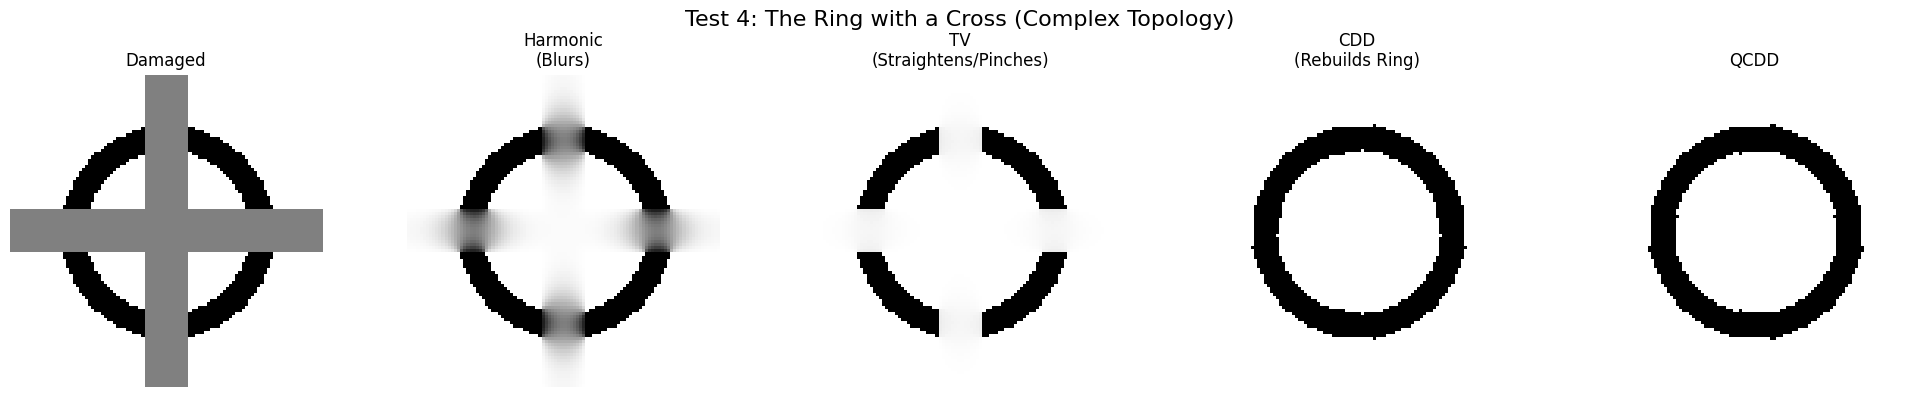

Saved: ring_cross_horizontal.pdf


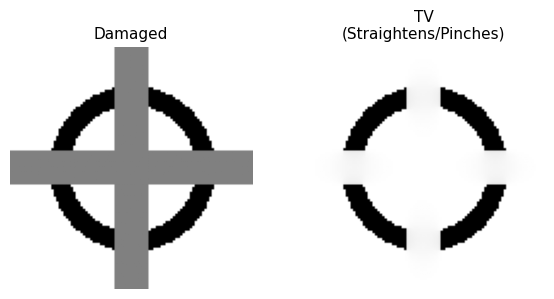

Saved: ring_cross_tv.pdf


In [30]:
# ==========================================
# CELL 4: The Ring with a Cross (Topology Test)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

def create_ring_with_cross(size=100, radius=30, thickness=8, cross_thickness=14):
    img = np.ones((size, size))
    Y, X = np.ogrid[:size, :size]
    dist_from_center = np.sqrt((X - size//2)**2 + (Y - size//2)**2)
    ring_mask = (dist_from_center >= radius - thickness/2) & (dist_from_center <= radius + thickness/2)
    img[ring_mask] = 0.0
    mask = np.zeros((size, size), dtype=bool)
    mask[:, size//2 - cross_thickness//2 : size//2 + cross_thickness//2] = True
    mask[size//2 - cross_thickness//2 : size//2 + cross_thickness//2, :] = True
    damaged = img.copy()
    damaged[mask] = 0.5
    return img, damaged, mask

original, damaged, mask = create_ring_with_cross()

print("Running Harmonic...")
h_res, _    = harmonic_inpaint(damaged, mask, max_iter=2000, verbose=False)
print("Running TV...")
tv_res, _   = tv_inpaint(damaged, mask, max_iter=2000, verbose=False)
print("Running CDD...")
cdd_res, _  = universal_cdd_inpaint(damaged, mask, verbose=True)
print("Running QCDD...")
qcdd_res, _ = universal_qcdd_inpaint(damaged, mask, verbose=True)

titles = ["Damaged", "Harmonic\n(Blurs)", "TV\n(Straightens/Pinches)", "CDD\n(Rebuilds Ring)", "QCDD"]
images = [damaged, h_res, tv_res, cdd_res, qcdd_res]

# ---- Horizontal (1x5) ----
fig_h, axes_h = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, title in zip(axes_h, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.suptitle("Test 4: The Ring with a Cross (Complex Topology)", fontsize=16)
plt.tight_layout()
plt.savefig('ring_cross_horizontal.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ring_cross_horizontal.pdf")

# ---- Damaged + TV side by side ----
fig_tv, axes_tv = plt.subplots(1, 2, figsize=(6, 3))

axes_tv[0].imshow(damaged, cmap='gray', vmin=0, vmax=1)
axes_tv[0].set_title('Damaged', fontsize=11)
axes_tv[0].axis('off')

axes_tv[1].imshow(tv_res, cmap='gray', vmin=0, vmax=1)
axes_tv[1].set_title('TV\n(Straightens/Pinches)', fontsize=11)
axes_tv[1].axis('off')

plt.tight_layout()
plt.savefig('ring_cross_tv.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ring_cross_tv.pdf")

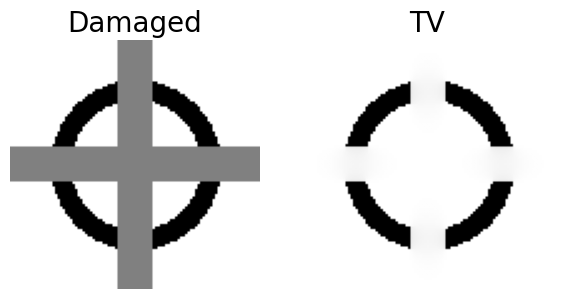

Saved: ring_cross_tv.pdf


In [34]:
# ---- Damaged + TV side by side ----
fig_tv, axes_tv = plt.subplots(1, 2, figsize=(6, 3))

axes_tv[0].imshow(damaged, cmap='gray', vmin=0, vmax=1)
axes_tv[0].set_title('Damaged', fontsize=20)
axes_tv[0].axis('off')

axes_tv[1].imshow(tv_res, cmap='gray', vmin=0, vmax=1)
axes_tv[1].set_title('TV', fontsize=20)
axes_tv[1].axis('off')

plt.tight_layout()
plt.savefig('ring_cross_tv.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ring_cross_tv.pdf")

Running Harmonic...
Running TV...
Running CDD...
Auto-detected mode: structure
Gap radius: 9.0px
  Init: Boundary mean (for structure connection)
  Phase 1: Harmonic (1500 iters)
  Phase 2: CDD (10000 iters, p=2.5, σ=2.0)
Running QCDD...
Auto-detected mode: structure
Gap radius: 9.0px
  Init: Boundary mean (for structure connection)
  Phase 1: Harmonic (1500 iters)
  Phase 2: QCDD (10000 iters, p=2.5, σ=2.0)
    Converged at iter 9503
Saved: ring_x.pdf


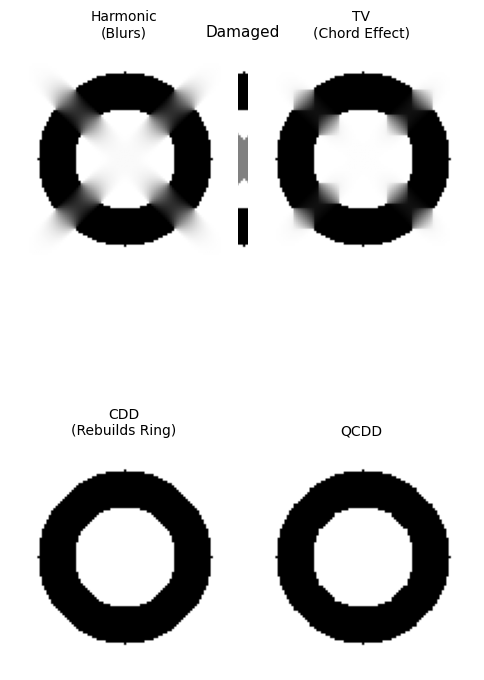

In [37]:
# ==========================================
# CELL 4: The Ring with an X (Topology Test)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def create_ring_with_x(size=100, radius=30, thickness=16, x_thickness=12):
    img = np.ones((size, size))
    Y, X = np.ogrid[:size, :size]
    center = size // 2
    dist_from_center = np.sqrt((X - center)**2 + (Y - center)**2)
    ring_mask = (dist_from_center >= radius - thickness/2) & (dist_from_center <= radius + thickness/2)
    img[ring_mask] = 0.0
    mask = np.zeros((size, size), dtype=bool)
    half_thick = x_thickness / 2
    for y in range(size):
        for x in range(size):
            dist_nw_se = abs((x - center) - (y - center)) / np.sqrt(2)
            dist_ne_sw = abs((x - center) + (y - center)) / np.sqrt(2)
            if dist_nw_se < half_thick or dist_ne_sw < half_thick:
                mask[y, x] = True
    damaged = img.copy()
    damaged[mask] = 0.5
    return img, damaged, mask

original, damaged, mask = create_ring_with_x(thickness=16, x_thickness=12)

print("Running Harmonic...")
h_res, _    = harmonic_inpaint(damaged, mask, max_iter=2000, verbose=False)
print("Running TV...")
tv_res, _   = tv_inpaint(damaged, mask, max_iter=10000, verbose=False)
print("Running CDD...")
cdd_res, _  = universal_cdd_inpaint(damaged, mask, verbose=True)
print("Running QCDD...")
qcdd_res, _ = universal_qcdd_inpaint(damaged, mask, verbose=True)

# ---- Layout: damaged centered on top, 2x2 grid below ----
fig = plt.figure(figsize=(6, 9))
gs  = GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.1)

# Damaged: centered across top row using middle two columns
ax_top = fig.add_subplot(gs[0, 1:3])
ax_top.imshow(damaged, cmap='gray', vmin=0, vmax=1)
ax_top.set_title('Damaged', fontsize=11)
ax_top.axis('off')

# 2x2 grid of model results
grid_items = [
    (h_res,    'Harmonic\n(Blurs)',       0, 0),
    (tv_res,   'TV\n(Chord Effect)',      0, 1),
    (cdd_res,  'CDD\n(Rebuilds Ring)',    1, 0),
    (qcdd_res, 'QCDD',                   1, 1),
]

for img, title, row, col in grid_items:
    ax = fig.add_subplot(gs[row + 0, col * 2 : col * 2 + 2])
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.savefig('ring_x.pdf', bbox_inches='tight', dpi=150)
print("Saved: ring_x.pdf")
plt.show()

Saved: ring_x.pdf


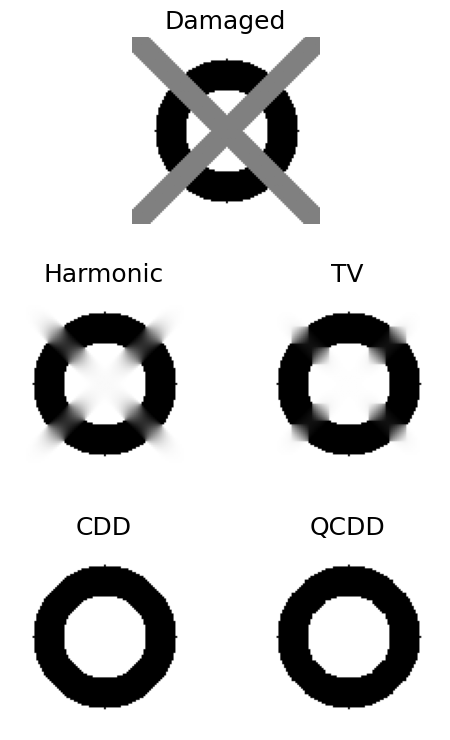

In [38]:
# ---- Replot ring_x: damaged on top, 2x2 below ----
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(6, 9))
gs  = GridSpec(3, 2, figure=fig,
               height_ratios=[1, 1, 1],
               hspace=0.35, wspace=0.1)

# Damaged: spans both columns of row 0
ax_top = fig.add_subplot(gs[0, :])
ax_top.imshow(damaged, cmap='gray', vmin=0, vmax=1)
ax_top.set_title('Damaged', fontsize=18)
ax_top.axis('off')

# 2x2 grid in rows 1 and 2
grid_items = [
    (h_res,    'Harmonic',    1, 0),
    (tv_res,   'TV',   1, 1),
    (cdd_res,  'CDD', 2, 0),
    (qcdd_res, 'QCDD',                2, 1),
]

for img, title, row, col in grid_items:
    ax = fig.add_subplot(gs[row, col])
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=18)
    ax.axis('off')

plt.savefig('ring_x.pdf', bbox_inches='tight', dpi=150)
print("Saved: ring_x.pdf")
plt.show()

Running Harmonic...
Running TV...
Running CDD...
Auto-detected mode: structure
Gap radius: 8.5px
  Init: Boundary mean (for structure connection)
  Phase 1: Harmonic (1500 iters)
  Phase 2: CDD (10000 iters, p=2.5, σ=2.0)
Running QCDD...
Gap radius: 8.5px
Regime: Large
  Phase 1: Harmonic warm-up (1500 iters)
  Phase 2: QCDD (10000 iters, p=2.5, σ=2.0)
    Iter   500 | max Δu = 0.000703
    Iter  1000 | max Δu = 0.000446
    Iter  1500 | max Δu = 0.000210
    Iter  2000 | max Δu = 0.000423
    Iter  2500 | max Δu = 0.000274
    Iter  3000 | max Δu = 0.000119
    Iter  3500 | max Δu = 0.000086
    Iter  4000 | max Δu = 0.000122
    Iter  4500 | max Δu = 0.000272
    Iter  5000 | max Δu = 0.000124
    Iter  5500 | max Δu = 0.000051
    Iter  6000 | max Δu = 0.000033
    Iter  6500 | max Δu = 0.000036
    Iter  7000 | max Δu = 0.000039
    Iter  7500 | max Δu = 0.000046
    Iter  8000 | max Δu = 0.000050
    Iter  8500 | max Δu = 0.000052
    Iter  9000 | max Δu = 0.000059
    Iter  9500 

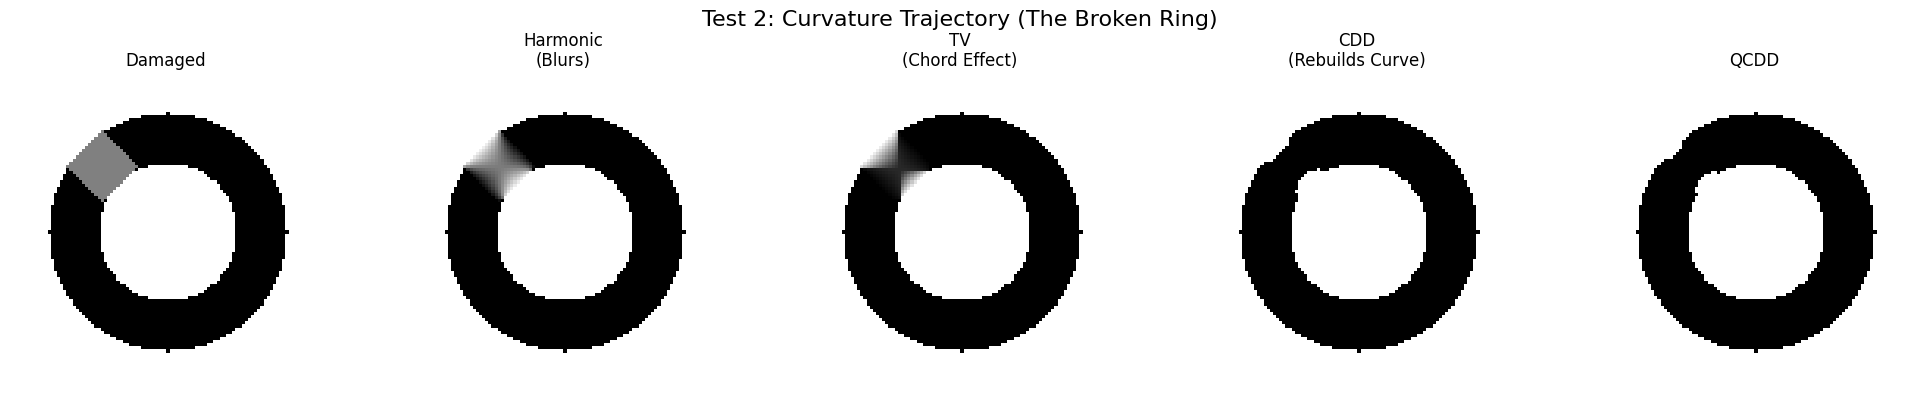

In [ ]:
# ==========================================
# CELL 2: The Broken Ring (Curve Following)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

def create_broken_ring_nw_diagonal(size=100, radius=30, thickness=16, gap_length=24, gap_width=16):
    """Ring with diagonal gap in NW quadrant. Gap = Thickness for chord effect."""
    Y, X = np.ogrid[:size, :size]
    center = size // 2
    dist_from_center = np.sqrt((X - center)**2 + (Y - center)**2)

    img = np.ones((size, size))
    ring_mask = (dist_from_center >= radius - thickness/2) & (dist_from_center <= radius + thickness/2)
    img[ring_mask] = 0.0

    mask = np.zeros((size, size), dtype=bool)

    # NW quadrant center point on the ring
    angle = np.radians(135)  # 135 degrees = NW direction
    gap_center_x = center + int(radius * np.cos(angle))
    gap_center_y = center - int(radius * np.sin(angle))

    for y in range(size):
        for x in range(size):
            dx = x - gap_center_x
            dy = y - gap_center_y

            # Rotate coordinates by 45 degrees (NW direction)
            diag_parallel = (dx - dy) / np.sqrt(2)
            diag_perp = (dx + dy) / np.sqrt(2)

            if abs(diag_parallel) < gap_length / 2 and abs(diag_perp) < gap_width / 2:
                mask[y, x] = True

    damaged = img.copy()
    damaged[mask] = 0.5
    return img, damaged, mask

# Use gap = thickness (16 vs 16)
original, damaged, mask = create_broken_ring_nw_diagonal(thickness=16, gap_length=16, gap_width=16)

print("Running Harmonic...")
h_res, _ = harmonic_inpaint(damaged, mask, max_iter=2000, verbose=False)

print("Running TV...")
tv_res, _ = tv_inpaint(damaged, mask, max_iter=5000, verbose=False)

print("Running CDD...")
cdd_res, _ = universal_cdd_inpaint(damaged, mask, verbose=True)

print("Running QCDD...")
qcdd_res, _ = universal_qcdd_inpaint(damaged, mask, verbose=True)

# Plotting
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ["Damaged", "Harmonic\n(Blurs)", "TV\n(Chord Effect)", "CDD\n(Rebuilds Curve)", "QCDD"]
images = [damaged, h_res, tv_res, cdd_res, qcdd_res]
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.suptitle("Test 2: Curvature Trajectory (The Broken Ring)", fontsize=16)
plt.tight_layout()
plt.show()

Running Harmonic...
Running TV...
Running CDD...
Auto-detected mode: structure
Gap radius: 6.0px
  Init: Boundary mean (for structure connection)
  Phase 1: Harmonic (600 iters)
  Phase 2: CDD (7000 iters, p=2.0, σ=2.0)
Running QCDD...
Gap radius: 6.0px
Regime: Medium
  Phase 1: Harmonic warm-up (600 iters)
  Phase 2: QCDD (7000 iters, p=2.0, σ=2.0)
    Iter   500 | max Δu = 0.000261
    Iter  1000 | max Δu = 0.000100
    Iter  1500 | max Δu = 0.000063
    Iter  2000 | max Δu = 0.000043
    Iter  2500 | max Δu = 0.000037
    Iter  3000 | max Δu = 0.000032
    Iter  3500 | max Δu = 0.000027
    Iter  4000 | max Δu = 0.000023
    Iter  4500 | max Δu = 0.000020
    Iter  5000 | max Δu = 0.000018
    Iter  5500 | max Δu = 0.000016
    Iter  6000 | max Δu = 0.000015
    Iter  6500 | max Δu = 0.000014
    Iter  7000 | max Δu = 0.000013


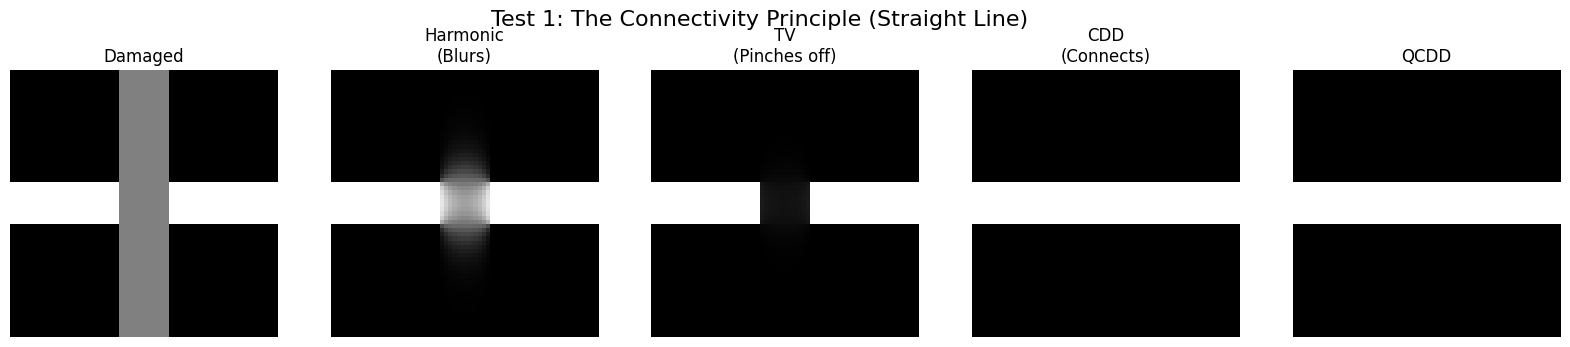

In [ ]:
# ==========================================
# CELL 1: The Broken Bar (Connectivity Test)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

def create_broken_bar(size=64, bar_width=8, gap_width=20):
    img = np.zeros((size, size))
    img[size//2 - bar_width//2 : size//2 + bar_width//2, :] = 1.0

    mask = np.zeros((size, size), dtype=bool)
    mask[:, size//2 - gap_width//2 : size//2 + gap_width//2] = True

    damaged = img.copy()
    damaged[mask] = 0.5
    return img, damaged, mask

original, damaged, mask = create_broken_bar(size=64, bar_width=10, gap_width=12)

print("Running Harmonic...")
h_res, _ = harmonic_inpaint(damaged, mask, max_iter=2000, verbose=False)

print("Running TV...")
tv_res, _ = tv_inpaint(damaged, mask, max_iter=2000, verbose=False)

print("Running CDD...")
# The universal wrapper autonomously calculates parameters based on gap width
# and automatically applies the academic binarization threshold.
cdd_res, _ = universal_cdd_inpaint(damaged, mask, verbose=True)

print("Running QCDD...")
qcdd_res, _ = universal_qcdd_inpaint(damaged, mask, verbose=True)

# Plotting
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ["Damaged", "Harmonic\n(Blurs)", "TV\n(Pinches off)", "CDD\n(Connects)", "QCDD"]
images = [damaged, h_res, tv_res, cdd_res, qcdd_res]
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.suptitle("Test 1: The Connectivity Principle (Straight Line)", fontsize=16)
plt.show()

# Quantitative Comparison w/ Photos

Image: astronaut (256x256)
Mask size: 2985 pixels (4.6%)
Running Harmonic...
Running TV...
Running CDD...
Running QCDD...

Model        PSNR (dB)    SSIM        
Harmonic     30.21        0.9737      
TV           28.67        0.9721      
CDD          31.73        0.9795      
QCDD         31.58        0.9786      
Best PSNR: CDD
Best SSIM: CDD


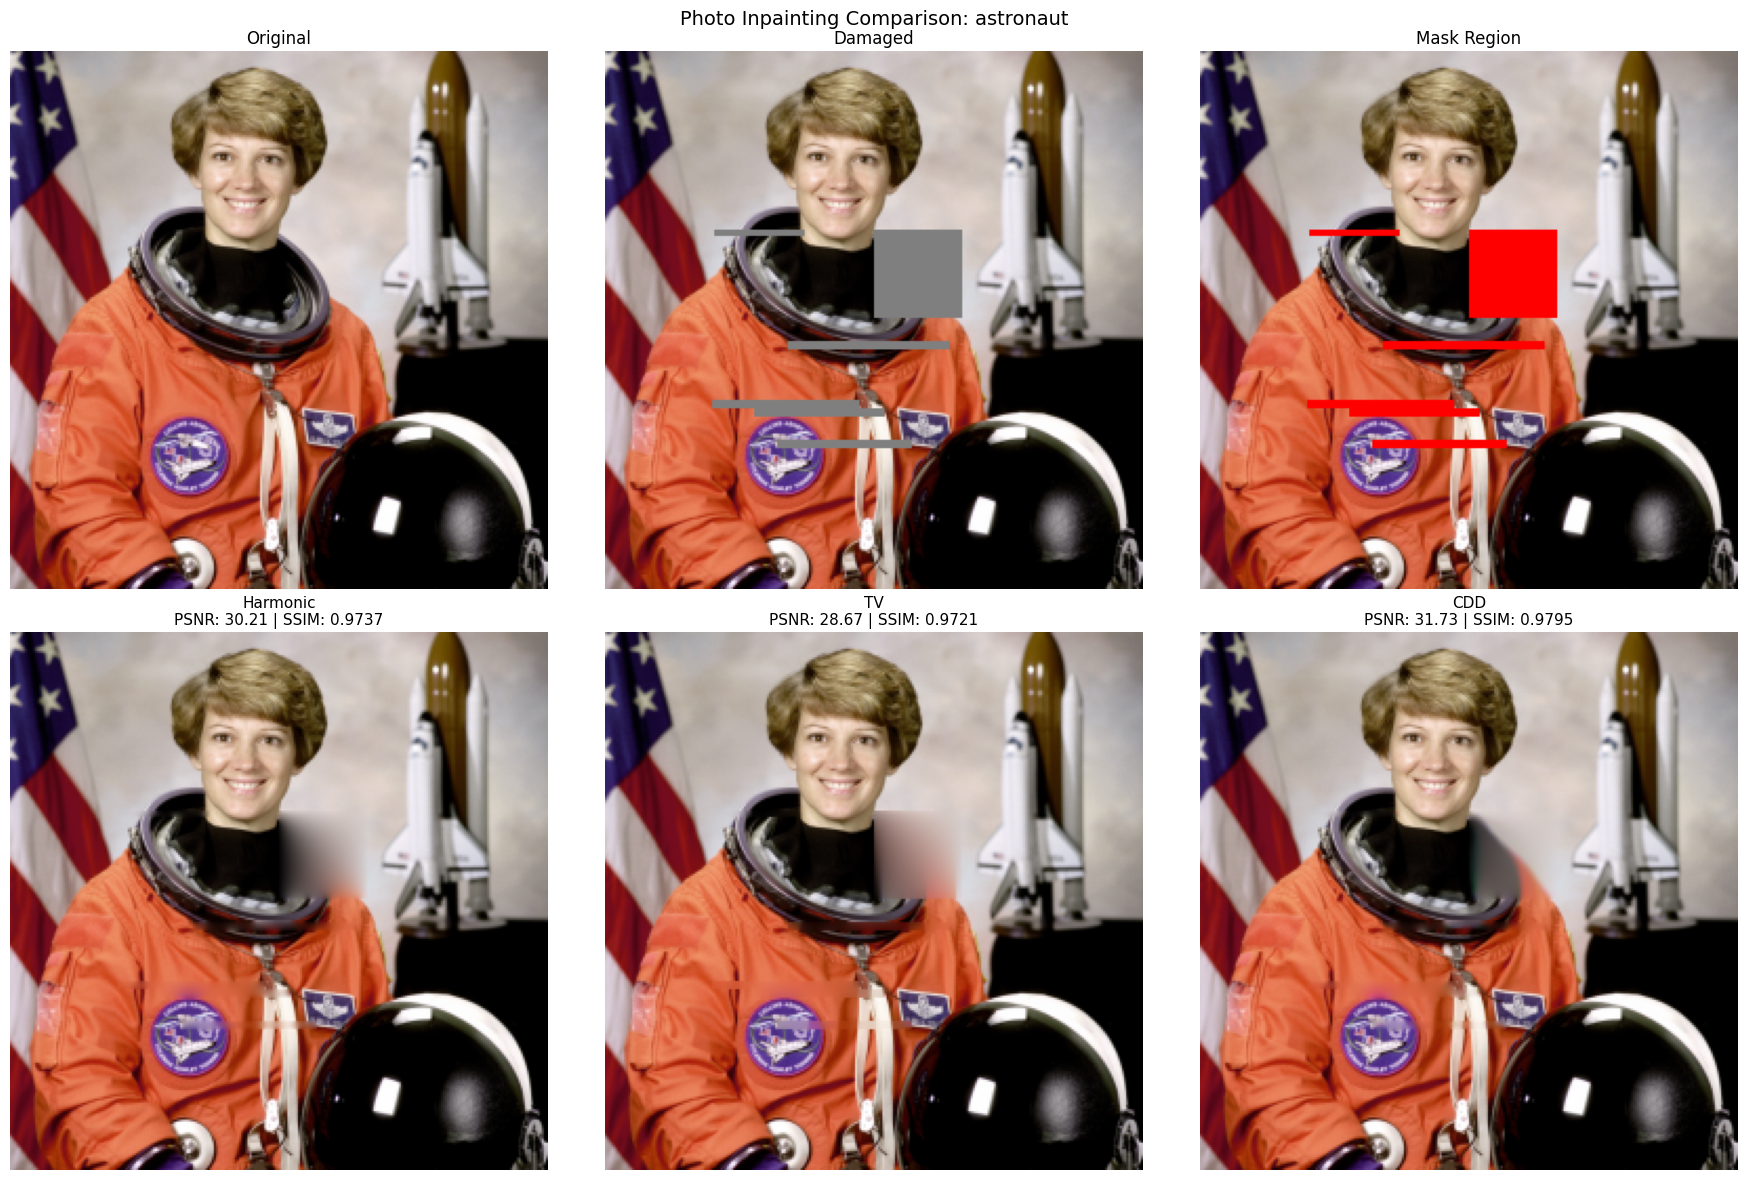

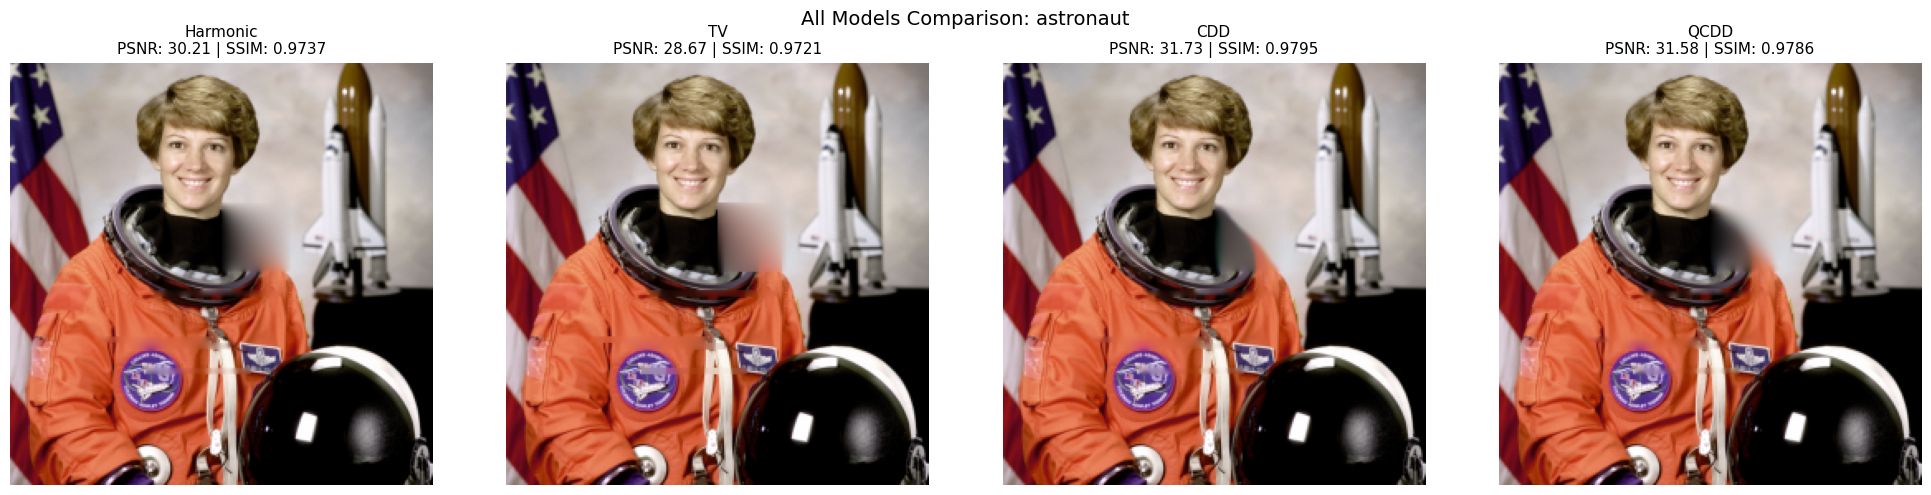

In [21]:
# ==========================================
# CELL: Photo Inpainting Comparison with Metrics
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import binary_dilation

# ==========================================
# CHANGE THIS TO TEST DIFFERENT IMAGES
# ==========================================
# Options: 'astronaut', 'camera', 'chelsea', 'coffee', 'horse'
IMAGE_NAME = 'astronaut'

# Load and resize image
def load_test_image(name, size=256):
    if name == 'astronaut':
        img = data.astronaut()
    elif name == 'camera':
        img = np.stack([data.camera()]*3, axis=-1)  # Convert grayscale to RGB
    elif name == 'chelsea':
        img = data.chelsea()
    elif name == 'coffee':
        img = data.coffee()
    elif name == 'horse':
        img = data.horse()
        img = np.stack([img]*3, axis=-1)  # Convert grayscale to RGB
    else:
        raise ValueError(f"Unknown image: {name}")

    # Resize to target size
    img = resize(img, (size, size, 3), anti_aliasing=True)
    return img.astype(np.float64)

# Create damage mask (rectangular + scattered scratches)
def create_photo_damage_mask(size=256, seed=42):
    np.random.seed(seed)
    mask = np.zeros((size, size), dtype=bool)

    # Add a rectangular block (simulating missing region)
    block_size = size // 6
    start_y, start_x = size // 3, size // 2
    mask[start_y:start_y + block_size, start_x:start_x + block_size] = True

    # Add some random scratches
    for _ in range(5):
        y = np.random.randint(size // 4, 3 * size // 4)
        x_start = np.random.randint(0, size // 2)
        x_end = x_start + np.random.randint(size // 6, size // 3)
        thickness = np.random.randint(2, 5)
        mask[y:y+thickness, x_start:x_end] = True

    return mask

# Inpaint each channel separately for RGB
def inpaint_rgb(image, mask, method='harmonic', **kwargs):
    result = np.zeros_like(image)
    for c in range(3):
        if method == 'harmonic':
            result[:,:,c], _ = harmonic_inpaint(image[:,:,c], mask, **kwargs)
        elif method == 'tv':
            result[:,:,c], _ = tv_inpaint(image[:,:,c], mask, **kwargs)
        elif method == 'cdd':
            # Universal wrapper handles RGB and auto-detects photo mode
            result, _ = universal_cdd_inpaint(image, mask, mode='photo', verbose=False)
            return np.clip(result, 0, 1)

        elif method == 'qcdd':
            # Universal wrapper handles RGB and auto-detects photo mode
            result, _ = universal_qcdd_inpaint(image, mask, mode='photo', verbose=False)

    return np.clip(result, 0, 1)

# Load image and create damage
original = load_test_image(IMAGE_NAME, size=256)
mask = create_photo_damage_mask(size=256)

# Create damaged image
damaged = original.copy()
damaged[mask] = 0.5  # Gray fill

print(f"Image: {IMAGE_NAME} (256x256)")
print(f"Mask size: {mask.sum()} pixels ({100*mask.mean():.1f}%)")
print("=" * 60)

# Run all 4 models
print("Running Harmonic...")
harmonic_res = inpaint_rgb(damaged, mask, method='harmonic', max_iter=3000, verbose=False)

print("Running TV...")
tv_res = inpaint_rgb(damaged, mask, method='tv', max_iter=3000, verbose=False)

print("Running CDD...")
cdd_res = inpaint_rgb(damaged, mask, method='cdd')

print("Running QCDD...")
qcdd_res = inpaint_rgb(damaged, mask, method='qcdd')

# Calculate metrics (only in the masked region for fairness)
def calculate_metrics(original, result, mask):
    # Full image metrics
    p = psnr(original, result, data_range=1.0)
    s = ssim(original, result, data_range=1.0, channel_axis=2)
    return p, s

results = {
    'Harmonic': harmonic_res,
    'TV': tv_res,
    'CDD': cdd_res,
    'QCDD': qcdd_res
}

print("\n" + "=" * 60)
print(f"{'Model':<12} {'PSNR (dB)':<12} {'SSIM':<12}")
print("=" * 60)

metrics = {}
for name, result in results.items():
    p, s = calculate_metrics(original, result, mask)
    metrics[name] = {'psnr': p, 'ssim': s}
    print(f"{name:<12} {p:<12.2f} {s:<12.4f}")

# Find best model
best_psnr = max(metrics.items(), key=lambda x: x[1]['psnr'])[0]
best_ssim = max(metrics.items(), key=lambda x: x[1]['ssim'])[0]
print("=" * 60)
print(f"Best PSNR: {best_psnr}")
print(f"Best SSIM: {best_ssim}")

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top row: Original, Damaged, and zoomed comparison
axes[0, 0].imshow(original)
axes[0, 0].set_title("Original", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(damaged)
axes[0, 1].set_title("Damaged", fontsize=12)
axes[0, 1].axis('off')

# Show mask
mask_overlay = original.copy()
mask_overlay[mask] = [1, 0, 0]  # Red overlay
axes[0, 2].imshow(mask_overlay)
axes[0, 2].set_title("Mask Region", fontsize=12)
axes[0, 2].axis('off')

# Bottom row: All 4 results
axes[1, 0].imshow(harmonic_res)
axes[1, 0].set_title(f"Harmonic\nPSNR: {metrics['Harmonic']['psnr']:.2f} | SSIM: {metrics['Harmonic']['ssim']:.4f}", fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(tv_res)
axes[1, 1].set_title(f"TV\nPSNR: {metrics['TV']['psnr']:.2f} | SSIM: {metrics['TV']['ssim']:.4f}", fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].imshow(cdd_res)
axes[1, 2].set_title(f"CDD\nPSNR: {metrics['CDD']['psnr']:.2f} | SSIM: {metrics['CDD']['ssim']:.4f}", fontsize=11)
axes[1, 2].axis('off')

plt.suptitle(f"Photo Inpainting Comparison: {IMAGE_NAME}", fontsize=14)
plt.tight_layout()
plt.show()

# Additional plot with QCDD
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, result) in zip(axes2, results.items()):
    ax.imshow(result)
    ax.set_title(f"{name}\nPSNR: {metrics[name]['psnr']:.2f} | SSIM: {metrics[name]['ssim']:.4f}", fontsize=11)
    ax.axis('off')
plt.suptitle(f"All Models Comparison: {IMAGE_NAME}", fontsize=14)
plt.tight_layout()
plt.show()

# Grid Search for Param. Tuning on CDD/QCDD

Loading image: camera (256x256)
Mask size: 3051 pixels (4.7%)

Total CDD configurations: 81
Total QCDD configurations: 243

>>> Running CDD Grid Search...
  CDD Progress: 20/81
  CDD Progress: 40/81
  CDD Progress: 60/81
  CDD Progress: 80/81

>>> Running QCDD Grid Search...
  QCDD Progress: 30/243
  QCDD Progress: 60/243
  QCDD Progress: 90/243
  QCDD Progress: 120/243
  QCDD Progress: 150/243
  QCDD Progress: 180/243
  QCDD Progress: 210/243
  QCDD Progress: 240/243

RESULTS

>>> Best CDD (by PSNR):
    PSNR: 29.0591
    SSIM: 0.9734
    Params: {'phase1_iters': 500, 'main_iters': 3000, 'p': 1.2, 'sigma': 0.0, 'eps_tv': 0.001}

>>> Best CDD (by SSIM):
    PSNR: 29.0440
    SSIM: 0.9735
    Params: {'phase1_iters': 500, 'main_iters': 2000, 'p': 1.2, 'sigma': 0.0, 'eps_tv': 0.001}

>>> Best QCDD (by PSNR):
    PSNR: 29.4601
    SSIM: 0.9725
    Params: {'phase1_iters': 500, 'main_iters': 3000, 'p': 1.2, 'sigma': 0.5, 'eps_tv': 0.001, 'dt': 0.6}

>>> Best QCDD (by SSIM):
    PSNR: 29.17

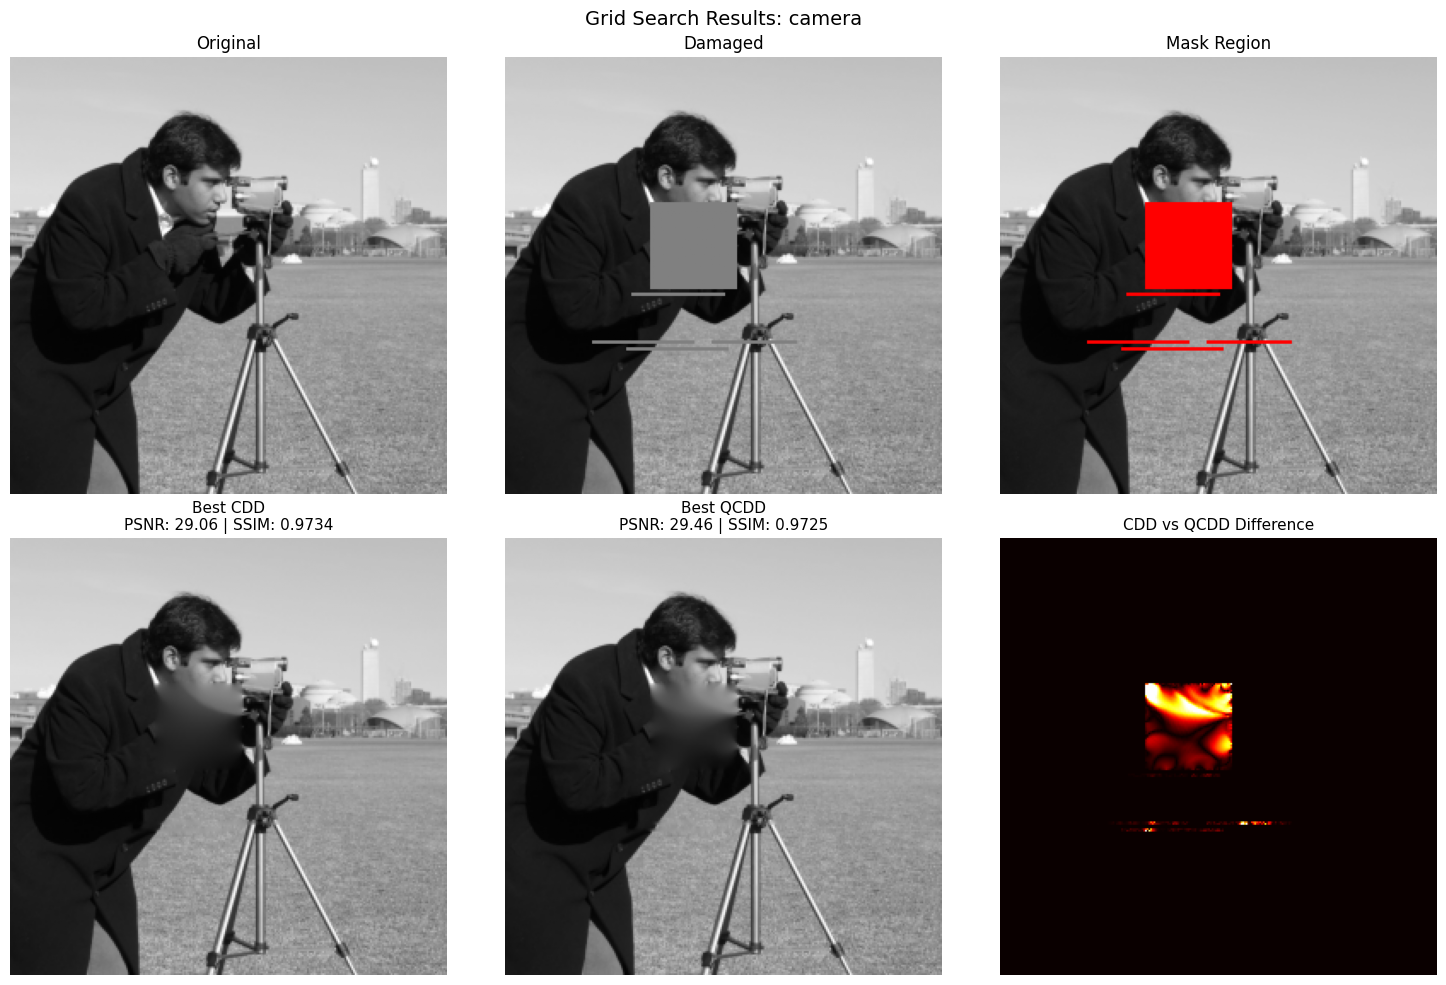


TOP 5 CDD CONFIGURATIONS (by PSNR)
1. PSNR: 29.0591, SSIM: 0.9734
   {'phase1_iters': 500, 'main_iters': 3000, 'p': 1.2, 'sigma': 0.0, 'eps_tv': 0.001}
2. PSNR: 29.0582, SSIM: 0.9734
   {'phase1_iters': 300, 'main_iters': 3000, 'p': 1.2, 'sigma': 0.0, 'eps_tv': 0.001}
3. PSNR: 29.0557, SSIM: 0.9734
   {'phase1_iters': 300, 'main_iters': 3000, 'p': 1.2, 'sigma': 0.3, 'eps_tv': 0.001}
4. PSNR: 29.0507, SSIM: 0.9734
   {'phase1_iters': 100, 'main_iters': 3000, 'p': 1.2, 'sigma': 0.0, 'eps_tv': 0.001}
5. PSNR: 29.0440, SSIM: 0.9735
   {'phase1_iters': 500, 'main_iters': 2000, 'p': 1.2, 'sigma': 0.0, 'eps_tv': 0.001}

TOP 5 QCDD CONFIGURATIONS (by PSNR)
1. PSNR: 29.4601, SSIM: 0.9725
   {'phase1_iters': 500, 'main_iters': 3000, 'p': 1.2, 'sigma': 0.5, 'eps_tv': 0.001, 'dt': 0.6}
2. PSNR: 29.4594, SSIM: 0.9725
   {'phase1_iters': 100, 'main_iters': 3000, 'p': 1.2, 'sigma': 0.5, 'eps_tv': 0.001, 'dt': 0.6}
3. PSNR: 29.4445, SSIM: 0.9725
   {'phase1_iters': 500, 'main_iters': 3000, 'p': 1.2, 

In [7]:
# ==========================================
# CELL: Grid Search for CDD/QCDD Hyperparameters
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import gaussian_filter, binary_dilation, distance_transform_edt
import itertools
from tqdm import tqdm  # For progress bar (optional: pip install tqdm)

# ==========================================
# CONFIGURATION
# ==========================================
IMAGE_NAME = 'camera'  # Options: 'camera', 'coins', 'moon', 'brick'
IMAGE_SIZE = 256
SEED = 42

# ==========================================
# Load grayscale image
# ==========================================
def load_grayscale_image(name, size=256):
    if name == 'camera':
        img = data.camera()
    elif name == 'coins':
        img = data.coins()
    elif name == 'moon':
        img = data.moon()
    elif name == 'brick':
        img = data.brick()
    else:
        raise ValueError(f"Unknown image: {name}")

    img = resize(img, (size, size), anti_aliasing=True)
    return img.astype(np.float64)

# ==========================================
# Create damage mask
# ==========================================
def create_damage_mask(size=256, seed=42):
    np.random.seed(seed)
    mask = np.zeros((size, size), dtype=bool)

    # Central block
    block_size = size // 5
    start = size // 3
    mask[start:start + block_size, start:start + block_size] = True

    # Random scratches
    for _ in range(4):
        y = np.random.randint(size // 4, 3 * size // 4)
        x_start = np.random.randint(0, size // 2)
        x_end = x_start + np.random.randint(size // 8, size // 4)
        thickness = np.random.randint(2, 4)
        mask[y:y+thickness, x_start:x_end] = True

    return mask

# ==========================================
# CDD with configurable parameters (grayscale only)
# ==========================================
def cdd_gray_configurable(image, mask, phase1_iters=300, cdd_iters=1000,
                           p=1.0, sigma=0.5, eps_tv=0.001, dt=0.02):
    """CDD for grayscale with all parameters exposed."""
    u = image.copy().astype(np.float64)

    # Nearest-boundary init (photo mode)
    dilated = binary_dilation(mask)
    boundary = dilated & ~mask
    if np.any(boundary):
        dist, indices = distance_transform_edt(~boundary, return_indices=True)
        my, mx = np.where(mask)
        u[my, mx] = image[indices[0][my, mx], indices[1][my, mx]]

    # Phase 1: Sharp TV warm-up
    eps_sq = eps_tv ** 2
    for _ in range(phase1_iters):
        u_pad = np.pad(u, 1, mode='edge')

        diff_E = u_pad[1:-1, 2:] - u_pad[1:-1, 1:-1]
        diff_W = u_pad[1:-1, :-2] - u_pad[1:-1, 1:-1]
        diff_N = u_pad[:-2, 1:-1] - u_pad[1:-1, 1:-1]
        diff_S = u_pad[2:, 1:-1] - u_pad[1:-1, 1:-1]

        G_E = 1.0 / np.sqrt(diff_E**2 + eps_sq)
        G_W = 1.0 / np.sqrt(diff_W**2 + eps_sq)
        G_N = 1.0 / np.sqrt(diff_N**2 + eps_sq)
        G_S = 1.0 / np.sqrt(diff_S**2 + eps_sq)

        u_new = (G_E*u_pad[1:-1,2:] + G_W*u_pad[1:-1,:-2] +
                 G_N*u_pad[:-2,1:-1] + G_S*u_pad[2:,1:-1]) / (G_E+G_W+G_N+G_S)
        u[mask] = u_new[mask]
        np.clip(u, 0, 1, out=u)

    # Phase 2: CDD
    eps_cdd = 1e-4
    for iteration in range(cdd_iters):
        u_old = u.copy()

        us = gaussian_filter(u, sigma=sigma) if sigma > 0 else u

        ux = (np.roll(us, -1, axis=1) - np.roll(us, 1, axis=1)) / 2.0
        uy = (np.roll(us, -1, axis=0) - np.roll(us, 1, axis=0)) / 2.0
        uxx = np.roll(us, -1, axis=1) - 2.0*us + np.roll(us, 1, axis=1)
        uyy = np.roll(us, -1, axis=0) - 2.0*us + np.roll(us, 1, axis=0)
        uxy = (np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)) / 2.0

        grad_mag = np.sqrt(ux**2 + uy**2 + eps_cdd**2)
        kappa = (uxx*uy**2 - 2*ux*uy*uxy + uyy*ux**2) / (grad_mag**3)

        G = (np.abs(kappa) ** p) / grad_mag
        G = np.clip(G, 0, 10.0)

        G_pad = np.pad(G, 1, mode='edge')
        G_E = 0.5 * (G_pad[1:-1, 2:] + G_pad[1:-1, 1:-1])
        G_W = 0.5 * (G_pad[1:-1, :-2] + G_pad[1:-1, 1:-1])
        G_N = 0.5 * (G_pad[:-2, 1:-1] + G_pad[1:-1, 1:-1])
        G_S = 0.5 * (G_pad[2:, 1:-1] + G_pad[1:-1, 1:-1])

        u_pad = np.pad(u, 1, mode='edge')
        divergence = (G_E * (u_pad[1:-1,2:] - u_pad[1:-1,1:-1]) +
                     G_W * (u_pad[1:-1,:-2] - u_pad[1:-1,1:-1]) +
                     G_N * (u_pad[:-2,1:-1] - u_pad[1:-1,1:-1]) +
                     G_S * (u_pad[2:,1:-1] - u_pad[1:-1,1:-1]))

        u[mask] = u[mask] + dt * divergence[mask]
        np.clip(u, 0, 1, out=u)

        if np.max(np.abs(u[mask] - u_old[mask])) < 1e-6:
            break

    return u

# ==========================================
# QCDD with configurable parameters (grayscale only)
# ==========================================
def qcdd_gray_configurable(image, mask, phase1_iters=300, qcdd_iters=1000,
                            p=1.0, sigma=0.5, eps_tv=0.001, dt=0.25):
    """QCDD for grayscale with all parameters exposed."""
    u = image.copy().astype(np.float64)

    # Nearest-boundary init (photo mode)
    dilated = binary_dilation(mask)
    boundary = dilated & ~mask
    if np.any(boundary):
        dist, indices = distance_transform_edt(~boundary, return_indices=True)
        my, mx = np.where(mask)
        u[my, mx] = image[indices[0][my, mx], indices[1][my, mx]]

    # Phase 1: Sharp TV warm-up
    eps_sq = eps_tv ** 2
    for _ in range(phase1_iters):
        u_pad = np.pad(u, 1, mode='edge')

        diff_E = u_pad[1:-1, 2:] - u_pad[1:-1, 1:-1]
        diff_W = u_pad[1:-1, :-2] - u_pad[1:-1, 1:-1]
        diff_N = u_pad[:-2, 1:-1] - u_pad[1:-1, 1:-1]
        diff_S = u_pad[2:, 1:-1] - u_pad[1:-1, 1:-1]

        G_E = 1.0 / np.sqrt(diff_E**2 + eps_sq)
        G_W = 1.0 / np.sqrt(diff_W**2 + eps_sq)
        G_N = 1.0 / np.sqrt(diff_N**2 + eps_sq)
        G_S = 1.0 / np.sqrt(diff_S**2 + eps_sq)

        u_new = (G_E*u_pad[1:-1,2:] + G_W*u_pad[1:-1,:-2] +
                 G_N*u_pad[:-2,1:-1] + G_S*u_pad[2:,1:-1]) / (G_E+G_W+G_N+G_S)
        u[mask] = u_new[mask]
        np.clip(u, 0, 1, out=u)

    # Phase 2: QCDD
    eps_qcdd = 1e-4
    for iteration in range(qcdd_iters):
        u_old = u.copy()

        us = gaussian_filter(u, sigma=sigma) if sigma > 0 else u

        ux = (np.roll(us, -1, axis=1) - np.roll(us, 1, axis=1)) / 2.0
        uy = (np.roll(us, -1, axis=0) - np.roll(us, 1, axis=0)) / 2.0
        uxx = np.roll(us, -1, axis=1) - 2.0*us + np.roll(us, 1, axis=1)
        uyy = np.roll(us, -1, axis=0) - 2.0*us + np.roll(us, 1, axis=0)
        uxy = (np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)) / 2.0

        grad_mag = np.sqrt(ux**2 + uy**2 + eps_qcdd**2)
        kappa = (uxx*uy**2 - 2*ux*uy*uxy + uyy*ux**2) / (grad_mag**3)

        G = np.abs(kappa) ** p
        G = np.clip(G, 0, 10.0)

        G_pad = np.pad(G, 1, mode='edge')
        G_E = 0.5 * (G_pad[1:-1, 2:] + G_pad[1:-1, 1:-1])
        G_W = 0.5 * (G_pad[1:-1, :-2] + G_pad[1:-1, 1:-1])
        G_N = 0.5 * (G_pad[:-2, 1:-1] + G_pad[1:-1, 1:-1])
        G_S = 0.5 * (G_pad[2:, 1:-1] + G_pad[1:-1, 1:-1])

        u_pad = np.pad(u, 1, mode='edge')

        sum_G_u = (G_E * u_pad[1:-1, 2:] +
                   G_W * u_pad[1:-1, :-2] +
                   G_N * u_pad[:-2, 1:-1] +
                   G_S * u_pad[2:, 1:-1])

        sum_G = G_E + G_W + G_N + G_S + 1e-10

        u_new = (u + dt * sum_G_u) / (1.0 + dt * sum_G)

        u[mask] = u_new[mask]
        np.clip(u, 0, 1, out=u)

        if np.max(np.abs(u[mask] - u_old[mask])) < 1e-6:
            break

    return u

# ==========================================
# GRID SEARCH PARAMETERS
# ==========================================
# Adjust these ranges based on computational budget

# param_grid = {
#     'phase1_iters': [100, 300, 500],
#     'main_iters': [500, 1000, 2000],
#     'p': [0.5, 1.0, 1.5],
#     'sigma': [0.0, 0.3, 0.5, 1.0],
#     'eps_tv': [0.0001, 0.001, 0.01],
# }

# # For QCDD-specific
# dt_values = [0.1, 0.25, 0.5]

param_grid = {
    'phase1_iters': [100, 300, 500],      # 300 was good, explore around it
    'main_iters': [1500, 2000, 3000],     # 1500 was best, try more
    'p': [0.8, 1.0, 1.2],                 # 1.0 was best, fine-tune around it
    'sigma': [0.0, 0.3, 0.5],             # Both 0.0 and 0.5 worked, add middle
    'eps_tv': [0.001],                    # Keep fixed (worked well)
}
dt_values = [0.4, 0.5, 0.6]               # 0.5 was best, fine-tune around it

# ==========================================
# RUN GRID SEARCH
# ==========================================
print(f"Loading image: {IMAGE_NAME} ({IMAGE_SIZE}x{IMAGE_SIZE})")
original = load_grayscale_image(IMAGE_NAME, IMAGE_SIZE)
mask = create_damage_mask(IMAGE_SIZE, SEED)
damaged = original.copy()
damaged[mask] = 0.5

print(f"Mask size: {mask.sum()} pixels ({100*mask.mean():.1f}%)")

# Generate all combinations
keys = ['phase1_iters', 'main_iters', 'p', 'sigma', 'eps_tv']
combinations = list(itertools.product(*[param_grid[k] for k in keys]))
total_cdd = len(combinations)
total_qcdd = len(combinations) * len(dt_values)

print(f"\nTotal CDD configurations: {total_cdd}")
print(f"Total QCDD configurations: {total_qcdd}")
print("=" * 60)

# Store results
cdd_results = []
qcdd_results = []

# ==========================================
# CDD Grid Search
# ==========================================
print("\n>>> Running CDD Grid Search...")
for i, combo in enumerate(combinations):
    params = dict(zip(keys, combo))

    if (i + 1) % 20 == 0:
        print(f"  CDD Progress: {i+1}/{total_cdd}")

    try:
        result = cdd_gray_configurable(
            damaged, mask,
            phase1_iters=params['phase1_iters'],
            cdd_iters=params['main_iters'],
            p=params['p'],
            sigma=params['sigma'],
            eps_tv=params['eps_tv'],
            dt=0.02  # Fixed for CDD
        )

        p_score = psnr(original, result, data_range=1.0)
        s_score = ssim(original, result, data_range=1.0)

        cdd_results.append({
            'params': params,
            'psnr': p_score,
            'ssim': s_score
        })
    except Exception as e:
        print(f"  CDD failed with {params}: {e}")

# ==========================================
# QCDD Grid Search
# ==========================================
print("\n>>> Running QCDD Grid Search...")
counter = 0
for combo in combinations:
    params = dict(zip(keys, combo))

    for dt in dt_values:
        counter += 1
        if counter % 30 == 0:
            print(f"  QCDD Progress: {counter}/{total_qcdd}")

        try:
            result = qcdd_gray_configurable(
                damaged, mask,
                phase1_iters=params['phase1_iters'],
                qcdd_iters=params['main_iters'],
                p=params['p'],
                sigma=params['sigma'],
                eps_tv=params['eps_tv'],
                dt=dt
            )

            p_score = psnr(original, result, data_range=1.0)
            s_score = ssim(original, result, data_range=1.0)

            qcdd_results.append({
                'params': {**params, 'dt': dt},
                'psnr': p_score,
                'ssim': s_score
            })
        except Exception as e:
            print(f"  QCDD failed with {params}, dt={dt}: {e}")

# ==========================================
# FIND BEST PARAMETERS
# ==========================================
print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)

# Best CDD by PSNR
best_cdd_psnr = max(cdd_results, key=lambda x: x['psnr'])
best_cdd_ssim = max(cdd_results, key=lambda x: x['ssim'])

# Best QCDD by PSNR
best_qcdd_psnr = max(qcdd_results, key=lambda x: x['psnr'])
best_qcdd_ssim = max(qcdd_results, key=lambda x: x['ssim'])

print("\n>>> Best CDD (by PSNR):")
print(f"    PSNR: {best_cdd_psnr['psnr']:.4f}")
print(f"    SSIM: {best_cdd_psnr['ssim']:.4f}")
print(f"    Params: {best_cdd_psnr['params']}")

print("\n>>> Best CDD (by SSIM):")
print(f"    PSNR: {best_cdd_ssim['psnr']:.4f}")
print(f"    SSIM: {best_cdd_ssim['ssim']:.4f}")
print(f"    Params: {best_cdd_ssim['params']}")

print("\n>>> Best QCDD (by PSNR):")
print(f"    PSNR: {best_qcdd_psnr['psnr']:.4f}")
print(f"    SSIM: {best_qcdd_psnr['ssim']:.4f}")
print(f"    Params: {best_qcdd_psnr['params']}")

print("\n>>> Best QCDD (by SSIM):")
print(f"    PSNR: {best_qcdd_ssim['psnr']:.4f}")
print(f"    SSIM: {best_qcdd_ssim['ssim']:.4f}")
print(f"    Params: {best_qcdd_ssim['params']}")

# ==========================================
# VISUALIZE BEST RESULTS
# ==========================================
# Run best configs
# Run best configs - need to rename 'main_iters' to the correct param name
cdd_params = best_cdd_psnr['params'].copy()
cdd_params['cdd_iters'] = cdd_params.pop('main_iters')  # Rename key

qcdd_params = best_qcdd_psnr['params'].copy()
qcdd_params['qcdd_iters'] = qcdd_params.pop('main_iters')  # Rename key

best_cdd_result = cdd_gray_configurable(damaged, mask, **cdd_params, dt=0.02)
best_qcdd_result = qcdd_gray_configurable(damaged, mask, **qcdd_params)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1
axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("Original", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(damaged, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title("Damaged", fontsize=12)
axes[0, 1].axis('off')

mask_overlay = np.stack([original, original, original], axis=-1)
mask_overlay[mask] = [1, 0, 0]
axes[0, 2].imshow(mask_overlay)
axes[0, 2].set_title("Mask Region", fontsize=12)
axes[0, 2].axis('off')

# Row 2
axes[1, 0].imshow(best_cdd_result, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title(f"Best CDD\nPSNR: {best_cdd_psnr['psnr']:.2f} | SSIM: {best_cdd_psnr['ssim']:.4f}", fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(best_qcdd_result, cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title(f"Best QCDD\nPSNR: {best_qcdd_psnr['psnr']:.2f} | SSIM: {best_qcdd_psnr['ssim']:.4f}", fontsize=11)
axes[1, 1].axis('off')

# Difference map
diff = np.abs(best_cdd_result - best_qcdd_result)
axes[1, 2].imshow(diff, cmap='hot', vmin=0, vmax=0.1)
axes[1, 2].set_title("CDD vs QCDD Difference", fontsize=11)
axes[1, 2].axis('off')

plt.suptitle(f"Grid Search Results: {IMAGE_NAME}", fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# TOP 5 RESULTS
# ==========================================
print("\n" + "=" * 60)
print("TOP 5 CDD CONFIGURATIONS (by PSNR)")
print("=" * 60)
top5_cdd = sorted(cdd_results, key=lambda x: x['psnr'], reverse=True)[:5]
for i, r in enumerate(top5_cdd):
    print(f"{i+1}. PSNR: {r['psnr']:.4f}, SSIM: {r['ssim']:.4f}")
    print(f"   {r['params']}")

print("\n" + "=" * 60)
print("TOP 5 QCDD CONFIGURATIONS (by PSNR)")
print("=" * 60)
top5_qcdd = sorted(qcdd_results, key=lambda x: x['psnr'], reverse=True)[:5]
for i, r in enumerate(top5_qcdd):
    print(f"{i+1}. PSNR: {r['psnr']:.4f}, SSIM: {r['ssim']:.4f}")
    print(f"   {r['params']}")

# Average PSNR/SSIM Bar Charts


--- astronaut ---
  Mask: 2030 px (3.10%)
  Harmonic...
  TV...
  CDD...
  QCDD...
    Harmonic    PSNR=32.21  SSIM=0.9836
    TV          PSNR=31.09  SSIM=0.9842
    CDD         PSNR=32.57  SSIM=0.9880
    QCDD        PSNR=32.44  SSIM=0.9861

--- camera ---
  Mask: 2030 px (3.10%)
  Harmonic...
  TV...
  CDD...
  QCDD...
    Harmonic    PSNR=30.62  SSIM=0.9838
    TV          PSNR=30.21  SSIM=0.9834
    CDD         PSNR=31.00  SSIM=0.9851
    QCDD        PSNR=31.92  SSIM=0.9855

--- chelsea ---
  Mask: 2030 px (3.10%)
  Harmonic...
  TV...
  CDD...
  QCDD...
    Harmonic    PSNR=36.67  SSIM=0.9876
    TV          PSNR=34.24  SSIM=0.9852
    CDD         PSNR=39.01  SSIM=0.9899
    QCDD        PSNR=39.03  SSIM=0.9902

--- coffee ---
  Mask: 2030 px (3.10%)
  Harmonic...
  TV...
  CDD...
  QCDD...
    Harmonic    PSNR=36.56  SSIM=0.9931
    TV          PSNR=36.45  SSIM=0.9922
    CDD         PSNR=38.78  SSIM=0.9949
    QCDD        PSNR=37.65  SSIM=0.9936

--- horse ---
  Mask: 2030 px (

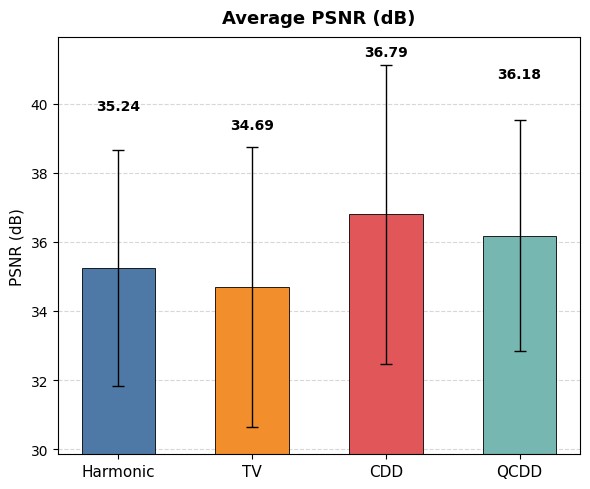

Saved: psnr_comparison.pdf


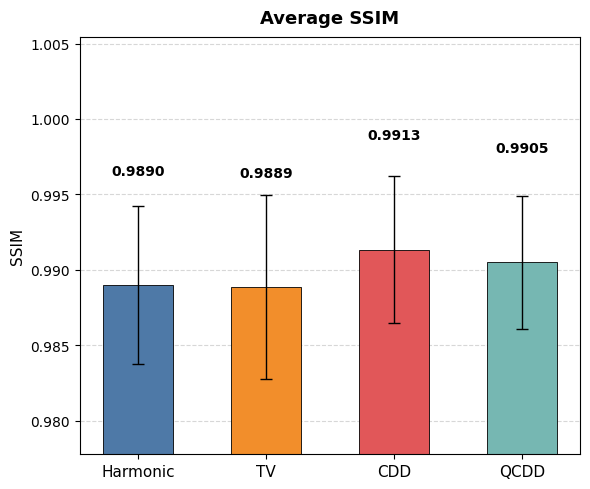

Saved: ssim_comparison.pdf

Running models on camera for qualitative figures...


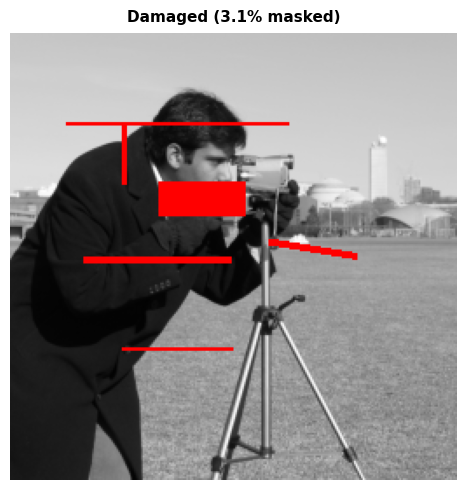

Saved: camera_damaged.pdf


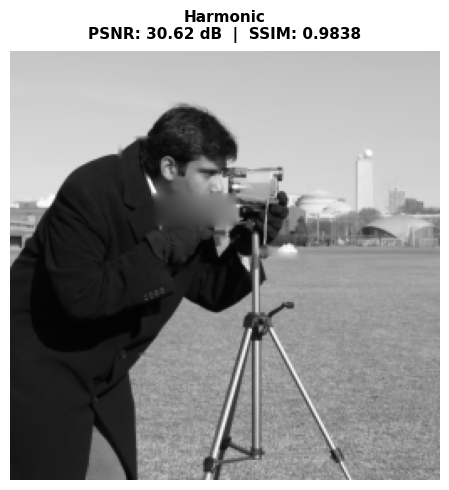

Saved: camera_harmonic.pdf


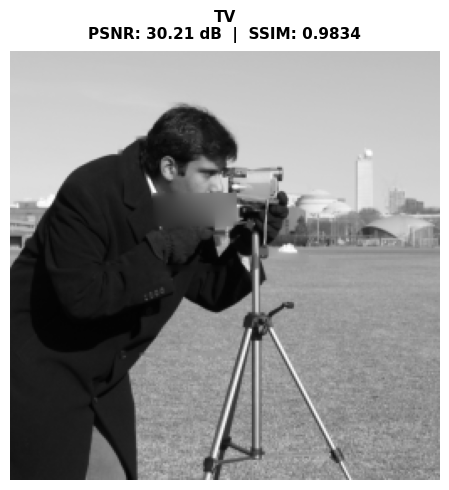

Saved: camera_tv.pdf


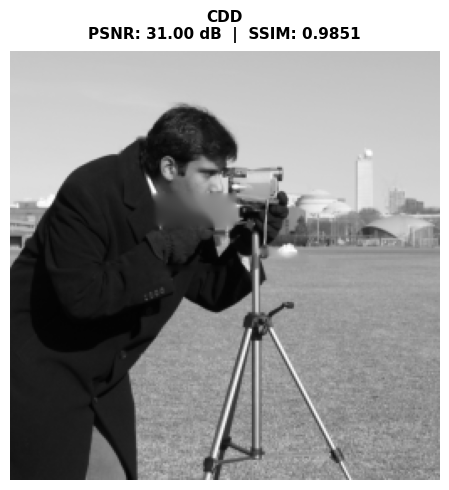

Saved: camera_cdd.pdf


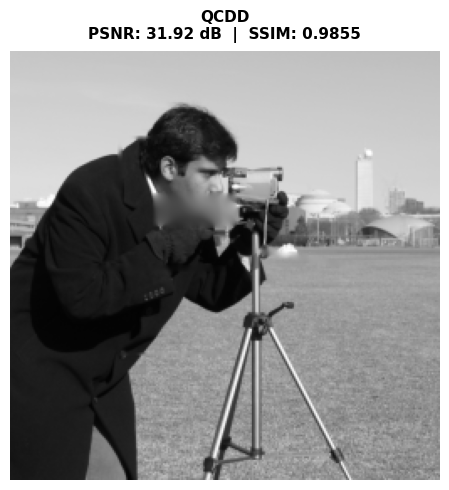

Saved: camera_qcdd.pdf


In [16]:
# ==========================================
# CELL: Averaged PSNR/SSIM Bar Charts (5 images)
# Best params from grid search on 'camera'
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# ---- BEST PARAMS FROM GRID SEARCH ----
# CDD best by PSNR: phase1=500, iters=3000, p=1.2, sigma=0.0
# QCDD best by PSNR: phase1=500, iters=3000, p=1.2, sigma=0.5, dt=0.6

IMAGE_SIZE = 256
SEED = 42

def load_rgb_image(name, size=256):
    loaders = {
        'astronaut': lambda: data.astronaut(),
        'camera':    lambda: np.stack([data.camera()]*3, axis=-1),
        'chelsea':   lambda: data.chelsea(),
        'coffee':    lambda: data.coffee(),
        'horse':     lambda: np.stack([
                         (data.horse().astype(np.float32) * 255).astype(np.uint8)
                     ]*3, axis=-1),
    }
    img = loaders[name]()
    img = resize(img, (size, size, 3), anti_aliasing=True)
    return img.astype(np.float64)

def create_realistic_damage_mask(size=256, seed=42):
    """
    Realistic damage: thin/thick scratches + ONE medium rectangle.
    Rectangle is large enough to stress-test models (~1.2% alone),
    scratches add ~0.8%, total ~2% — enough to differentiate models.
    """
    np.random.seed(seed)
    mask = np.zeros((size, size), dtype=bool)

    # --- Medium rectangle (tape / water damage) ---
    # ~20 tall x 50 wide: large enough that Harmonic blurs visibly
    # but not so large it dominates the whole image
    rh = 20
    rw = 50
    ry = size // 3                          # upper-mid region
    rx = size // 3
    mask[ry:ry+rh, rx:rx+rw] = True

    # --- 3 horizontal scratches of varying thickness ---
    scratch_configs = [
        (size // 5,           size // 8,  size // 2,  2),   # thin
        (size // 2,           size // 6,  size // 3,  4),   # medium
        (2 * size // 3 + 10,  size // 4,  size // 4,  2),   # thin
    ]
    for (y, x0, length, t) in scratch_configs:
        mask[y:y+t, x0:x0+length] = True

    # --- 1 diagonal thick scratch ---
    y0 = size // 2 - 10
    x0 = size // 2 + 20
    for k in range(size // 5):
        yy = y0 + k // 6
        xx = x0 + k
        if 0 <= yy+4 < size and 0 <= xx < size:
            mask[yy:yy+4, xx:xx+1] = True

    # --- 1 short vertical crease ---
    xc = size // 4
    y0c = size // 5
    mask[y0c:y0c + size//7, xc:xc+3] = True

    return mask

# def create_realistic_damage_mask(size=256, seed=42):
#     """
#     Scratches spread evenly across the image with enforced vertical separation.
#     No two damage elements overlap or cluster into an implicit rectangle.
#     """
#     np.random.seed(seed)
#     mask = np.zeros((size, size), dtype=bool)

#     # --- 4 horizontal scratches, evenly spaced vertically ---
#     # Force y positions to be in distinct quarters of the image
#     y_positions = [
#         np.random.randint(size // 8,        size // 4),        # top quarter
#         np.random.randint(size // 4 + 10,   size // 2 - 10),   # upper-mid
#         np.random.randint(size // 2 + 10,   3 * size // 4),    # lower-mid
#         np.random.randint(3 * size // 4 + 5, 7 * size // 8),   # bottom quarter
#     ]
#     thicknesses  = [2, 5, 2, 3]
#     x_starts     = [size // 10, size // 5, size // 8, size // 4]
#     lengths      = [int(size * 0.35), int(size * 0.40), int(size * 0.30), int(size * 0.35)]

#     for y, t, x0, l in zip(y_positions, thicknesses, x_starts, lengths):
#         mask[y:y+t, x0:x0+l] = True

#     # --- 1 short diagonal scratch in its own clear zone ---
#     # Constrained to the right half only so it can't overlap the horizontals
#     y0 = np.random.randint(size // 8, size // 4)
#     x0 = size // 2 + np.random.randint(0, size // 6)
#     length = int(size * 0.25)   # short — only 25% of image width
#     for k in range(length):
#         yy = y0 + k // 3
#         xx = x0 + k
#         if 0 <= yy + 4 < size and 0 <= xx < size:
#             mask[yy:yy+4, xx:xx+1] = True

#     # --- 1 short vertical crease, left side, own vertical band ---
#     xc  = np.random.randint(size // 8, size // 4)
#     y0c = np.random.randint(size // 3, size // 2)
#     mask[y0c : y0c + size // 8, xc : xc + 2] = True

#     return mask

# ---- Run all models on all images ----
IMAGE_NAMES = ['astronaut', 'camera', 'chelsea', 'coffee', 'horse']
all_metrics = {m: {'psnr': [], 'ssim': []} for m in ['Harmonic', 'TV', 'CDD', 'QCDD']}

for img_name in IMAGE_NAMES:
    print(f"\n--- {img_name} ---")
    original = load_rgb_image(img_name, IMAGE_SIZE)
    mask = create_realistic_damage_mask(IMAGE_SIZE, SEED)
    damaged = original.copy()
    damaged[mask] = 0.5

    print(f"  Mask: {mask.sum()} px ({100*mask.mean():.2f}%)")

    # Harmonic
    print("  Harmonic...")
    h = np.stack([harmonic_inpaint(damaged[:,:,c], mask, max_iter=3000, verbose=False)[0]
                  for c in range(3)], axis=-1)
    results_h = np.clip(h, 0, 1)

    # TV
    print("  TV...")
    t = np.stack([tv_inpaint(damaged[:,:,c], mask, max_iter=8000, verbose=False)[0]
                  for c in range(3)], axis=-1)
    results_t = np.clip(t, 0, 1)

    # CDD (best params by PSNR)
    print("  CDD...")
    results_cdd, _ = universal_cdd_inpaint(damaged, mask, mode='photo', verbose=False)
    results_cdd = np.clip(results_cdd, 0, 1)

    # QCDD (best params by PSNR)
    print("  QCDD...")
    results_qcdd, _ = universal_qcdd_inpaint(damaged, mask, mode='photo', verbose=False)
    results_qcdd = np.clip(results_qcdd, 0, 1)

    model_outputs = {
        'Harmonic': results_h,
        'TV':       results_t,
        'CDD':      results_cdd,
        'QCDD':     results_qcdd,
    }

    for mname, result in model_outputs.items():
        p = psnr(original, result, data_range=1.0)
        s = ssim(original, result, data_range=1.0, channel_axis=2)
        all_metrics[mname]['psnr'].append(p)
        all_metrics[mname]['ssim'].append(s)
        print(f"    {mname:10s}  PSNR={p:.2f}  SSIM={s:.4f}")

# ---- Averages ----
models   = ['Harmonic', 'TV', 'CDD', 'QCDD']
avg_psnr = [np.mean(all_metrics[m]['psnr']) for m in models]
avg_ssim = [np.mean(all_metrics[m]['ssim']) for m in models]
std_psnr = [np.std(all_metrics[m]['psnr'])  for m in models]
std_ssim = [np.std(all_metrics[m]['ssim'])  for m in models]

print("\n" + "="*52)
print(f"{'Model':<12} {'Avg PSNR':>10} {'±':>4} {'Avg SSIM':>10} {'±':>4}")
print("="*52)
for m, p, sp, s, ss in zip(models, avg_psnr, std_psnr, avg_ssim, std_ssim):
    print(f"{m:<12} {p:>10.2f} {sp:>4.2f} {s:>10.4f} {ss:>4.4f}")

# ---- Shared plot config ----
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
x      = np.arange(len(models))
width  = 0.55

# ---- PSNR Bar Chart ----
fig1, ax1 = plt.subplots(figsize=(6, 5))
bars1 = ax1.bar(x, avg_psnr, width, color=colors,
                edgecolor='black', linewidth=0.6,
                yerr=std_psnr, capsize=4, error_kw=dict(elinewidth=1))
ax1.set_title('Average PSNR (dB)', fontsize=13, fontweight='bold', pad=10)
ax1.set_xticks(x); ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylabel('PSNR (dB)', fontsize=11)
ax1.set_ylim(min(avg_psnr) - max(std_psnr) - 0.5,
             max(avg_psnr) + max(std_psnr) + 0.8)
for bar, val in zip(bars1, avg_psnr):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(std_psnr) + 0.15,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
fig1.tight_layout()
fig1.savefig('psnr_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: psnr_comparison.pdf")

# ---- SSIM Bar Chart ----
fig2, ax2 = plt.subplots(figsize=(6, 5))
bars2 = ax2.bar(x, avg_ssim, width, color=colors,
                edgecolor='black', linewidth=0.6,
                yerr=std_ssim, capsize=4, error_kw=dict(elinewidth=1))
ax2.set_title('Average SSIM', fontsize=13, fontweight='bold', pad=10)
ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=11)
ax2.set_ylabel('SSIM', fontsize=11)
ax2.set_ylim(min(avg_ssim) - max(std_ssim) - 0.005,
             max(avg_ssim) + max(std_ssim) + 0.008)
for bar, val in zip(bars2, avg_ssim):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(std_ssim) + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
fig2.tight_layout()
fig2.savefig('ssim_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ssim_comparison.pdf")

# ---- Qualitative individual PDFs ----
DEMO_IMAGE = 'camera'

demo_original = load_rgb_image(DEMO_IMAGE, IMAGE_SIZE)
demo_mask     = create_realistic_damage_mask(IMAGE_SIZE, SEED)
demo_damaged  = demo_original.copy()
demo_damaged[demo_mask] = 0.5

print(f"\nRunning models on {DEMO_IMAGE} for qualitative figures...")
demo_h = np.clip(np.stack([
    harmonic_inpaint(demo_damaged[:,:,c], demo_mask, max_iter=5000, verbose=False)[0]
    for c in range(3)], axis=-1), 0, 1)

demo_t = np.clip(np.stack([
    tv_inpaint(demo_damaged[:,:,c], demo_mask, max_iter=5000, verbose=False)[0]
    for c in range(3)], axis=-1), 0, 1)

demo_cdd,  _ = universal_cdd_inpaint(demo_damaged, demo_mask, mode='photo', verbose=False)
demo_qcdd, _ = universal_qcdd_inpaint(demo_damaged, demo_mask, mode='photo', verbose=False)
demo_cdd  = np.clip(demo_cdd,  0, 1)
demo_qcdd = np.clip(demo_qcdd, 0, 1)

def rgb_metrics(orig, result):
    p = psnr(orig, result, data_range=1.0)
    s = ssim(orig, result, data_range=1.0, channel_axis=2)
    return p, s

ph,   sh   = rgb_metrics(demo_original, demo_h)
pt,   st   = rgb_metrics(demo_original, demo_t)
pcdd, scdd = rgb_metrics(demo_original, demo_cdd)
pq,   sq   = rgb_metrics(demo_original, demo_qcdd)

mask_overlay = demo_original.copy()
mask_overlay[demo_mask] = [1.0, 0.0, 0.0]

items = [
    (mask_overlay, f'Damaged ({100*demo_mask.mean():.1f}% masked)', 'damaged',  None,  None),
    (demo_h,       'Harmonic',                                       'harmonic', ph,    sh),
    (demo_t,       'TV',                                             'tv',       pt,    st),
    (demo_cdd,     'CDD',                                            'cdd',      pcdd,  scdd),
    (demo_qcdd,    'QCDD',                                           'qcdd',     pq,    sq),
]

for img, title, fname, p_val, s_val in items:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    if p_val is not None:
        ax.set_title(f'{title}\nPSNR: {p_val:.2f} dB  |  SSIM: {s_val:.4f}',
                     fontsize=11, fontweight='bold', pad=8)
    else:
        ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{DEMO_IMAGE}_{fname}.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {DEMO_IMAGE}_{fname}.pdf")

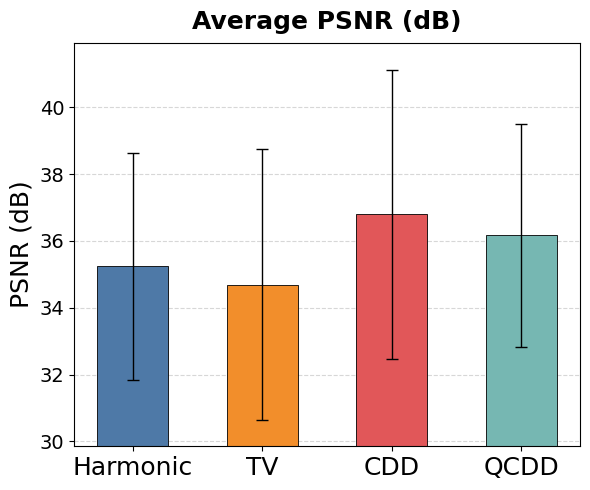

Saved: psnr_comparison.pdf


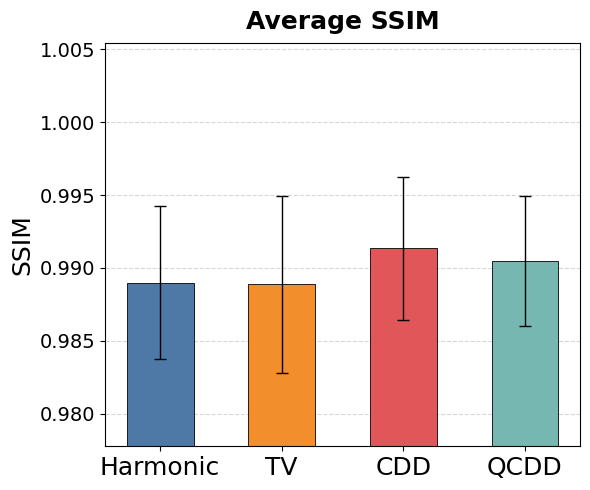

Saved: ssim_comparison.pdf


In [44]:
# ---- Resave bar charts without bold labels ----
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
x      = np.arange(len(models))
width  = 0.55

# ---- PSNR Bar Chart ----
fig1, ax1 = plt.subplots(figsize=(6, 5))
bars1 = ax1.bar(x, avg_psnr, width, color=colors,
                edgecolor='black', linewidth=0.6,
                yerr=std_psnr, capsize=4, error_kw=dict(elinewidth=1))
ax1.set_title('Average PSNR (dB)', fontsize=18, fontweight='bold', pad=10)
ax1.set_xticks(x); ax1.set_xticklabels(models, fontsize=18)
ax1.set_ylabel('PSNR (dB)', fontsize=18)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_ylim(min(avg_psnr) - max(std_psnr) - 0.5,
             max(avg_psnr) + max(std_psnr) + 0.8)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
fig1.tight_layout()
fig1.savefig('psnr_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: psnr_comparison.pdf")

# ---- SSIM Bar Chart ----
fig2, ax2 = plt.subplots(figsize=(6, 5))
bars2 = ax2.bar(x, avg_ssim, width, color=colors,
                edgecolor='black', linewidth=0.6,
                yerr=std_ssim, capsize=4, error_kw=dict(elinewidth=1))
ax2.set_title('Average SSIM', fontsize=18, fontweight='bold', pad=10)
ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=18)
ax2.set_ylabel('SSIM', fontsize=18)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_ylim(min(avg_ssim) - max(std_ssim) - 0.005,
             max(avg_ssim) + max(std_ssim) + 0.008)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
fig2.tight_layout()
fig2.savefig('ssim_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ssim_comparison.pdf")

# Final Astronaut Plots

Image: astronaut (256x256)
Mask size: 2985 pixels (4.6%)
Running Harmonic...
Running TV...
Running CDD...
Running QCDD...
Harmonic     PSNR=30.21  SSIM=0.9737
TV           PSNR=28.67  SSIM=0.9721
CDD          PSNR=31.73  SSIM=0.9795
QCDD         PSNR=31.58  SSIM=0.9786


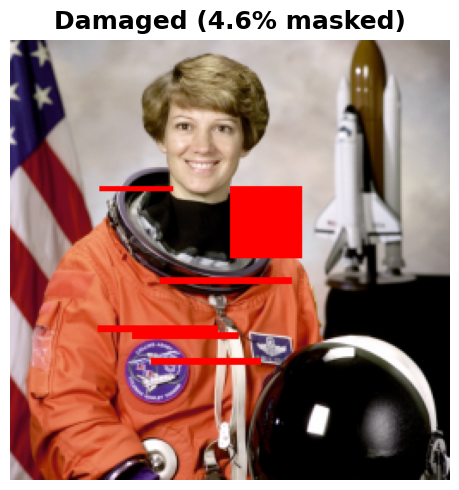

Saved: astronaut_damaged.pdf


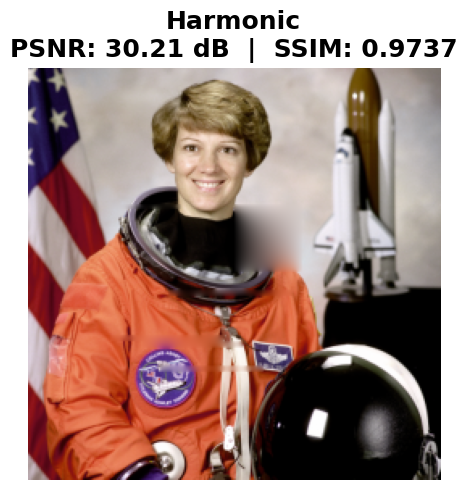

Saved: astronaut_harmonic.pdf


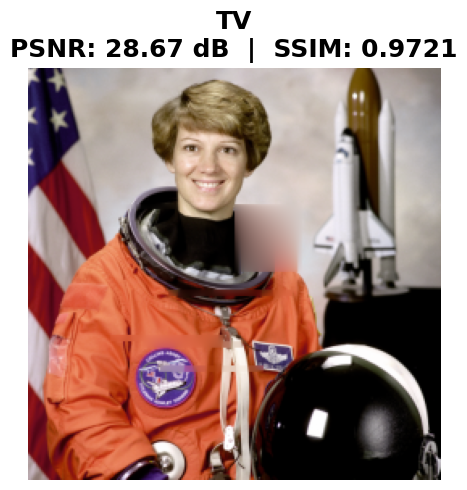

Saved: astronaut_tv.pdf


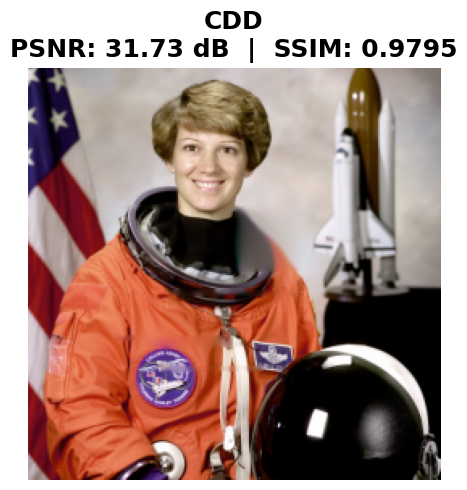

Saved: astronaut_cdd.pdf


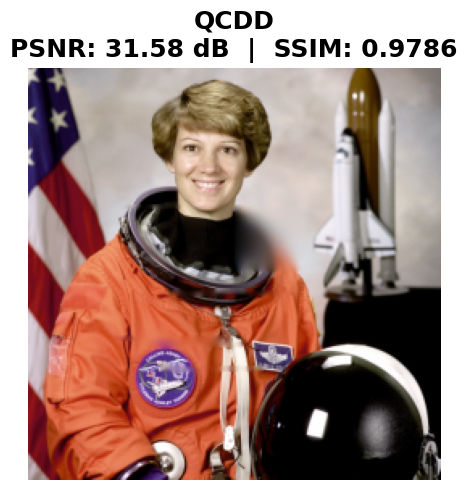

Saved: astronaut_qcdd.pdf


In [45]:
# ---- Same as photo comparison cell, but saves each output as a separate PDF ----
IMAGE_NAME = 'astronaut'

original = load_test_image(IMAGE_NAME, size=256)
mask     = create_photo_damage_mask(size=256, seed=42)
damaged  = original.copy()
damaged[mask] = 0.5

print(f"Image: {IMAGE_NAME} (256x256)")
print(f"Mask size: {mask.sum()} pixels ({100*mask.mean():.1f}%)")
print("=" * 60)

print("Running Harmonic...")
harmonic_res = inpaint_rgb(damaged, mask, method='harmonic', max_iter=3000, verbose=False)

print("Running TV...")
tv_res = inpaint_rgb(damaged, mask, method='tv', max_iter=3000, verbose=False)

print("Running CDD...")
cdd_res = inpaint_rgb(damaged, mask, method='cdd')

print("Running QCDD...")
qcdd_res = inpaint_rgb(damaged, mask, method='qcdd')

metrics = {}
for name, result in [('Harmonic', harmonic_res), ('TV', tv_res), ('CDD', cdd_res), ('QCDD', qcdd_res)]:
    p, s = calculate_metrics(original, result, mask)
    metrics[name] = {'psnr': p, 'ssim': s}
    print(f"{name:<12} PSNR={p:.2f}  SSIM={s:.4f}")

mask_overlay = original.copy()
mask_overlay[mask] = [1, 0, 0]

items = [
    (mask_overlay,  f'Damaged ({100*mask.mean():.1f}% masked)', 'damaged',  None, None),
    (harmonic_res,  'Harmonic',                                  'harmonic', metrics['Harmonic']['psnr'], metrics['Harmonic']['ssim']),
    (tv_res,        'TV',                                        'tv',       metrics['TV']['psnr'],       metrics['TV']['ssim']),
    (cdd_res,       'CDD',                                       'cdd',      metrics['CDD']['psnr'],      metrics['CDD']['ssim']),
    (qcdd_res,      'QCDD',                                      'qcdd',     metrics['QCDD']['psnr'],     metrics['QCDD']['ssim']),
]

for img, title, fname, p_val, s_val in items:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    if p_val is not None:
        ax.set_title(f'{title}\nPSNR: {p_val:.2f} dB  |  SSIM: {s_val:.4f}',
                     fontsize=18, fontweight='bold', pad=8)
    else:
        ax.set_title(title, fontsize=18, fontweight='bold', pad=8)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{IMAGE_NAME}_{fname}.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {IMAGE_NAME}_{fname}.pdf")

# Testing on Custom Photos

In [46]:
# CELL 0: Colab Stuff

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [47]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/pde_v2')


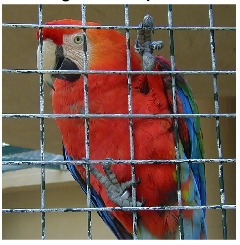

Image: 245x240  — Paint over damage, then click "Save Mask ✓", then run Cell 8b.
Mask saved: 14791 pixels (25.15%)
Mask saved: 15016 pixels (25.54%)
Mask saved: 15056 pixels (25.61%)


In [48]:
# CELL 8a: Interactive mask painter (HTML canvas — works in Colab)

import numpy as np
import base64, json
from PIL import Image as PILImage
from IPython.display import display, HTML
from google.colab import output
import io

IMAGE_PATH = '/content/drive/MyDrive/pde_v2/content/test_image_8.PNG'
original_rgb = load_image(IMAGE_PATH, grayscale=False)

# FIX: If the downscaled image is 2D, duplicate it into 3 channels for the RGB solver
if len(original_rgb.shape) == 2:
    original_rgb = np.stack((original_rgb, original_rgb, original_rgb), axis=-1)

H3, W3, _ = original_rgb.shape

# Encode image to base64 so we can display it in the canvas
img_uint8 = (np.clip(original_rgb, 0, 1) * 255).astype(np.uint8)
pil_img   = PILImage.fromarray(img_uint8)
buf       = io.BytesIO()
pil_img.save(buf, format='PNG')
img_b64   = base64.b64encode(buf.getvalue()).decode('utf-8')

# We'll store the mask here after the user clicks "Save Mask"
painted_mask = np.zeros((H3, W3), dtype=bool)

def save_mask(mask_b64):
    global painted_mask
    mask_bytes = base64.b64decode(mask_b64)
    mask_img   = PILImage.open(io.BytesIO(mask_bytes)).convert('L')
    mask_arr   = np.array(mask_img)
    painted_mask = mask_arr > 128
    print(f'Mask saved: {painted_mask.sum()} pixels ({100*painted_mask.mean():.2f}%)')

output.register_callback('save_mask', save_mask)

DISPLAY_W = min(W3, 700)
DISPLAY_H = int(H3 * DISPLAY_W / W3)

html = f"""
<div style="font-family: monospace; user-select: none;">
  <div style="margin-bottom:8px; display:flex; gap:12px; align-items:center;">
    <label>Brush size:
      <input id="brushRange" type="range" min="2" max="60" value="12"
             oninput="document.getElementById('brushVal').textContent=this.value">
      <span id="brushVal">12</span>px
    </label>
    <button onclick="clearMask()"
      style="padding:4px 12px; cursor:pointer;">Clear</button>
    <button onclick="saveMask()"
      style="padding:4px 14px; background:#2a7; color:#fff;
             border:none; border-radius:4px; cursor:pointer; font-size:14px;">
      Save Mask ✓
    </button>
    <span id="status" style="color:#888;"></span>
  </div>

  <div style="position:relative; width:{DISPLAY_W}px; height:{DISPLAY_H}px;">
    <!-- background: the original image -->
    <canvas id="imgCanvas" width="{DISPLAY_W}" height="{DISPLAY_H}"
            style="position:absolute; top:0; left:0;"></canvas>
    <!-- foreground: the red painted mask -->
    <canvas id="drawCanvas" width="{DISPLAY_W}" height="{DISPLAY_H}"
            style="position:absolute; top:0; left:0; opacity:0.45; cursor:crosshair;"></canvas>
  </div>
</div>

<script>
const IMG_W = {W3}, IMG_H = {H3};
const DISP_W = {DISPLAY_W}, DISP_H = {DISPLAY_H};

// Draw the photo onto the background canvas
const imgCanvas  = document.getElementById('imgCanvas');
const imgCtx     = imgCanvas.getContext('2d');
const drawCanvas = document.getElementById('drawCanvas');
const drawCtx    = drawCanvas.getContext('2d');

const photo = new Image();
photo.onload = () => imgCtx.drawImage(photo, 0, 0, DISP_W, DISP_H);
photo.src = 'data:image/png;base64,{img_b64}';

drawCtx.fillStyle = 'red';

let painting = false;

function getBrush() {{
  return parseInt(document.getElementById('brushRange').value);
}}

function getPos(e) {{
  const rect = drawCanvas.getBoundingClientRect();
  const clientX = e.touches ? e.touches[0].clientX : e.clientX;
  const clientY = e.touches ? e.touches[0].clientY : e.clientY;
  return {{
    x: clientX - rect.left,
    y: clientY - rect.top
  }};
}}

function paint(e) {{
  if (!painting) return;
  e.preventDefault();
  const {{x, y}} = getPos(e);
  const r = getBrush();
  drawCtx.beginPath();
  drawCtx.arc(x, y, r, 0, Math.PI * 2);
  drawCtx.fill();
}}

drawCanvas.addEventListener('mousedown',  e => {{ painting = true;  paint(e); }});
drawCanvas.addEventListener('mousemove',  paint);
drawCanvas.addEventListener('mouseup',    () => painting = false);
drawCanvas.addEventListener('mouseleave', () => painting = false);

function clearMask() {{
  drawCtx.clearRect(0, 0, DISP_W, DISP_H);
  document.getElementById('status').textContent = 'Cleared.';
}}

function saveMask() {{
  // Render mask at FULL resolution (not just display size)
  const fullCanvas = document.createElement('canvas');
  fullCanvas.width  = IMG_W;
  fullCanvas.height = IMG_H;
  const fullCtx = fullCanvas.getContext('2d');

  // Scale the drawn mask up to native image resolution
  fullCtx.drawImage(drawCanvas, 0, 0, IMG_W, IMG_H);

  // Export as grayscale: convert red pixels → white, rest → black
  const imageData = fullCtx.getImageData(0, 0, IMG_W, IMG_H);
  const grayCanvas = document.createElement('canvas');
  grayCanvas.width  = IMG_W;
  grayCanvas.height = IMG_H;
  const grayCtx = grayCanvas.getContext('2d');
  const grayData = grayCtx.createImageData(IMG_W, IMG_H);

  for (let i = 0; i < imageData.data.length; i += 4) {{
    const alpha = imageData.data[i + 3];   // painted pixels have alpha > 0
    const val   = alpha > 10 ? 255 : 0;
    grayData.data[i]     = val;
    grayData.data[i + 1] = val;
    grayData.data[i + 2] = val;
    grayData.data[i + 3] = 255;
  }}
  grayCtx.putImageData(grayData, 0, 0);

  const maskB64 = grayCanvas.toDataURL('image/png').split(',')[1];
  document.getElementById('status').textContent = 'Mask sent to Python...';
  google.colab.kernel.invokeFunction('save_mask', [maskB64], {{}});
  document.getElementById('status').textContent = 'Saved ✓';
}}
</script>
"""

display(HTML(html))
print(f'Image: {H3}x{W3}  — Paint over damage, then click "Save Mask ✓", then run Cell 8b.')

Running Adaptive CDD Inpainting on /content/drive/MyDrive/pde_v2/content/test_image_8.PNG...
Gap radius: 6.7px
  Init: Nearest-boundary (for edge preservation)
  Phase 1: Sharp TV (500 iters, eps=0.001)
  Phase 2: CDD (2000 iters, p=1.0, σ=0.5)


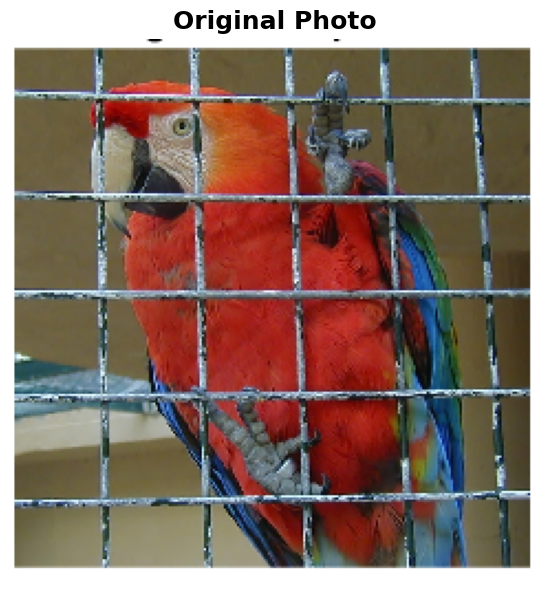

Saved: manual_original.pdf


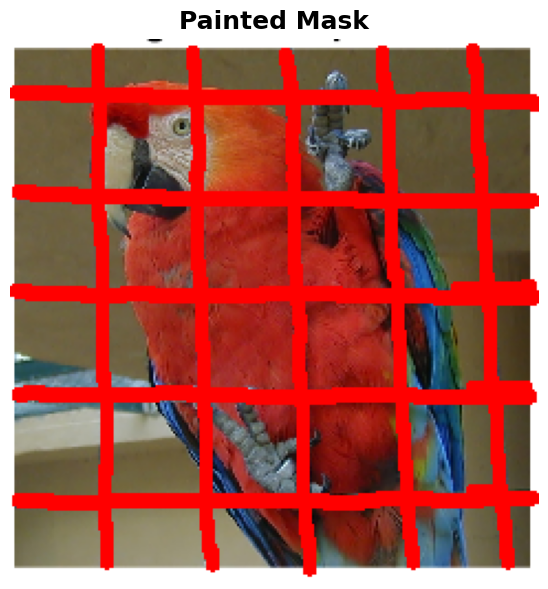

Saved: manual_masked.pdf


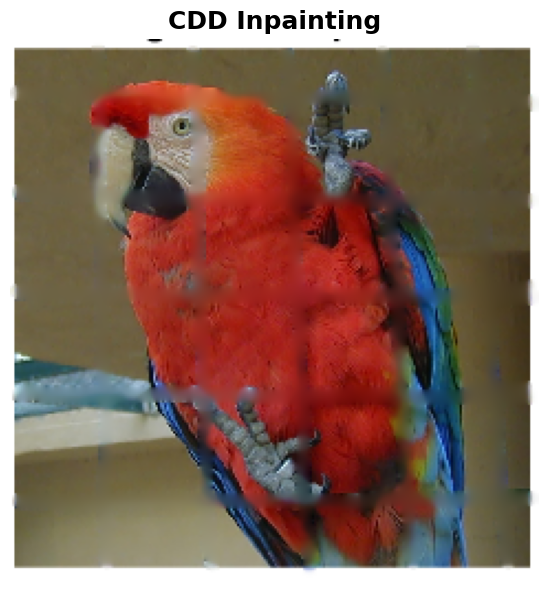

Saved: manual_cdd.pdf
Saved: /content/restored_cdd.jpg


/tmp/ipykernel_8937/119735401.py:54: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PILImage.fromarray(out, mode='RGB').save('/content/restored_cdd.jpg')


In [50]:
# Cell: Run Adaptive CDD on Photo
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage

# --- EXECUTION ---
if 'painted_mask' not in globals() or painted_mask.sum() == 0:
    print('Mask is empty — paint in Cell 8a and click Save Mask first.')
else:
    print(f"Running Adaptive CDD Inpainting on {IMAGE_PATH}...")

    # Best params from grid search: phase1=500, p=1.2, sigma=0.0, iters=3000
    restored_rgb, _ = universal_cdd_inpaint(
        original_rgb, painted_mask, mode='photo', verbose=True
    )
    restored_rgb = np.clip(restored_rgb, 0, 1)

    mask_overlay = original_rgb.copy()
    mask_overlay[painted_mask] = [1, 0, 0]

    # ---- Original ----
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(original_rgb)
    ax.set_title('Original Photo', fontsize=18, fontweight='bold', pad=8)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('manual_original.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: manual_original.pdf')

    # ---- Masked ----
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(mask_overlay)
    ax.set_title('Painted Mask', fontsize=18, fontweight='bold', pad=8)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('manual_masked.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: manual_masked.pdf')

    # ---- CDD Result ----
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(restored_rgb)
    ax.set_title('CDD Inpainting', fontsize=18, fontweight='bold', pad=8)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('manual_cdd.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: manual_cdd.pdf')

    # ---- Also save restored image as JPG ----
    out = (restored_rgb * 255).astype('uint8')
    PILImage.fromarray(out, mode='RGB').save('/content/restored_cdd.jpg')
    print('Saved: /content/restored_cdd.jpg')